In [2]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from scipy.signal import spectrogram
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report


In [3]:
data_path = '40Sen_30Sec_stomping_30sec_quiet.csv' 
data = pd.read_csv(data_path)
distances =  pd.read_csv('dist.csv')
print("Data shape:", data.shape)
print("First few rows:")
print(data.head())
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Data shape: (59999, 40)
First few rows:
    -0.0301  -0.00059605  -0.0044703  -0.0056624  -0.0083447  -0.0011921  \
0 -0.046492     0.003278   -0.005960   -0.009537   -0.008047    0.002980   
1 -0.059307     0.000000    0.001192   -0.008047   -0.006259   -0.000596   
2 -0.056624    -0.001192    0.008941    0.000596   -0.000596   -0.003874   
3 -0.039339    -0.000298    0.012815   -0.004470    0.001490   -0.001788   
4 -0.021160    -0.001192    0.013411   -0.012517   -0.001192    0.002384   

   -0.011623  -0.00089407  -0.00059605.1  -0.0098348  ...  0.0074506  \
0  -0.018775    -0.000894      -0.004470   -0.008345  ...   0.037849   
1  -0.014007     0.002682      -0.004470   -0.005960  ...   0.032187   
2  -0.005662     0.004172      -0.005662   -0.002682  ...   0.006259   
3   0.005662     0.005066      -0.008941    0.003278  ...  -0.032783   
4   0.014007     0.004172      -0.006556    0.006855  ...  -0.054836   

   0.010729  0.00029802  -0.0074506  -0.022352  0.068545  -0.010133  \

```markdown
### Data Preparation

In this notebook, we are working with audio data to distinguish between quiet and loud segments. The data is loaded from a CSV file and contains multiple columns representing different sensors.

1. **Loading Data**: We start by loading the data from the CSV file `40Sen_30Sec_stomping_30sec_quiet.csv`.
2. **Data Segmentation**: The data is segmented into quiet and noisy samples. The last 28 seconds of the data are considered quiet, and the rest is considered noisy.
3. **Saving Segments**: The segmented data is saved into separate CSV files for further analysis.

The variables used in this process include:
- `data`: The entire dataset loaded from the CSV file.
- `quiet_samples`: The last 28 seconds of the data, representing quiet segments.
- `noisy_samples`: The remaining data, representing noisy segments.

Next, we will focus on learning the characteristics of the quiet segments and later remove these characteristics from the loud segments.
```

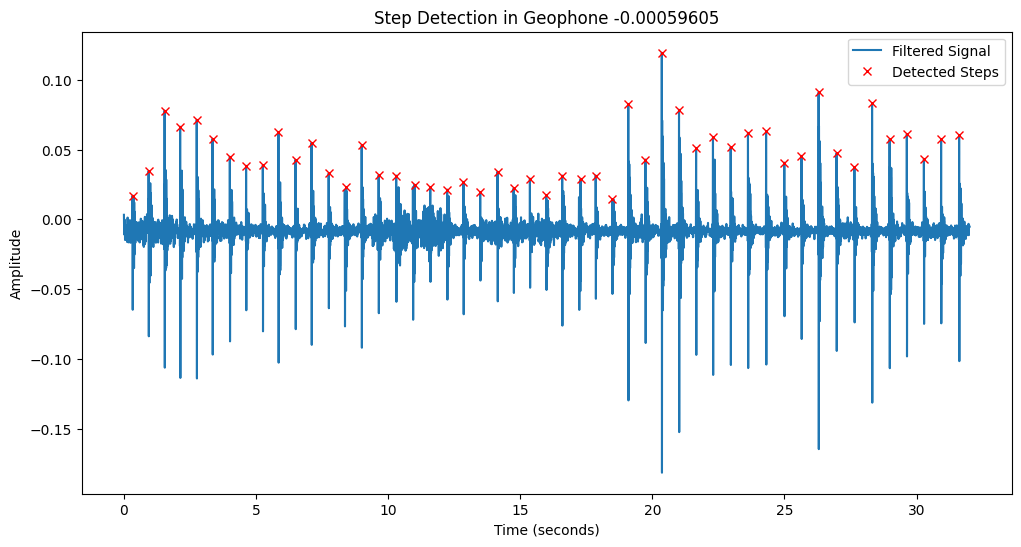

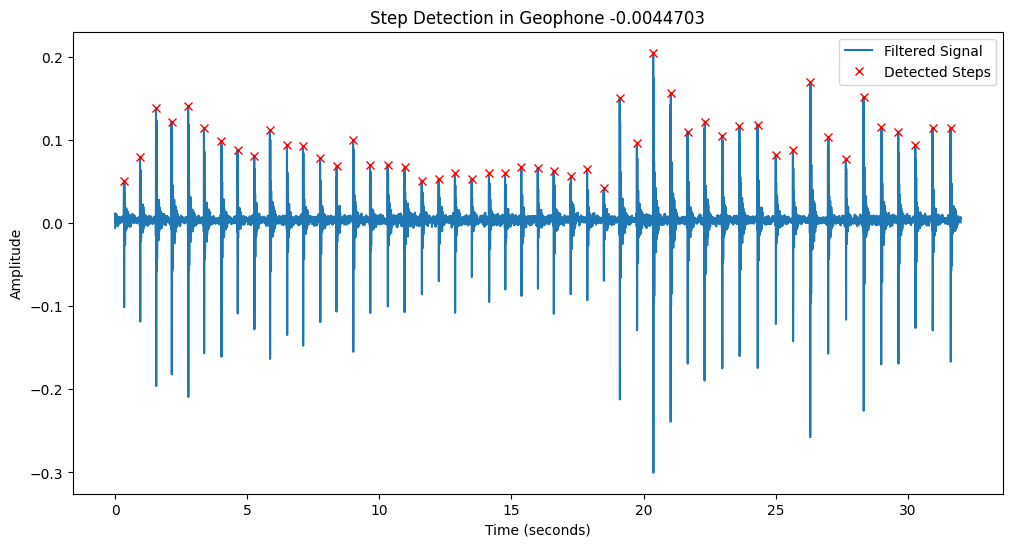

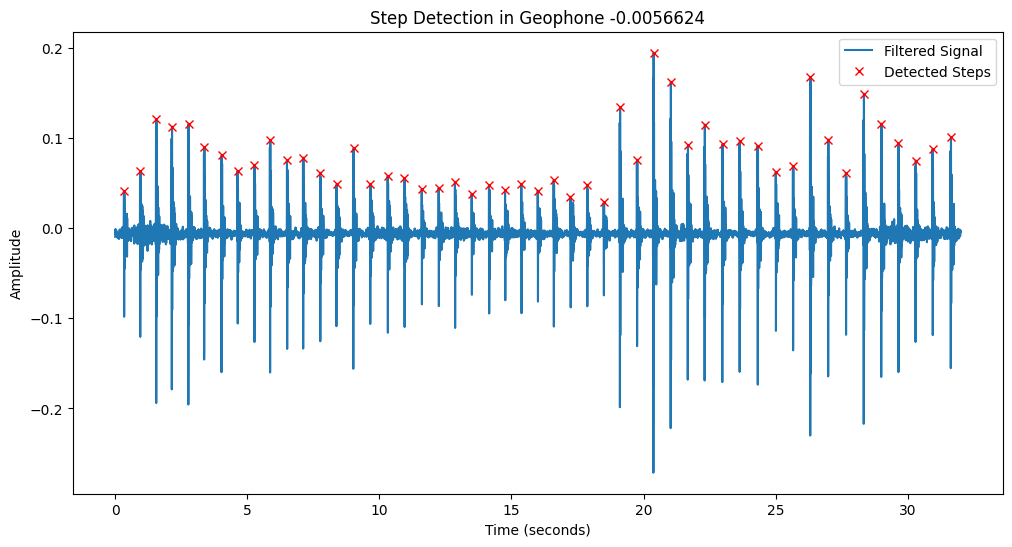

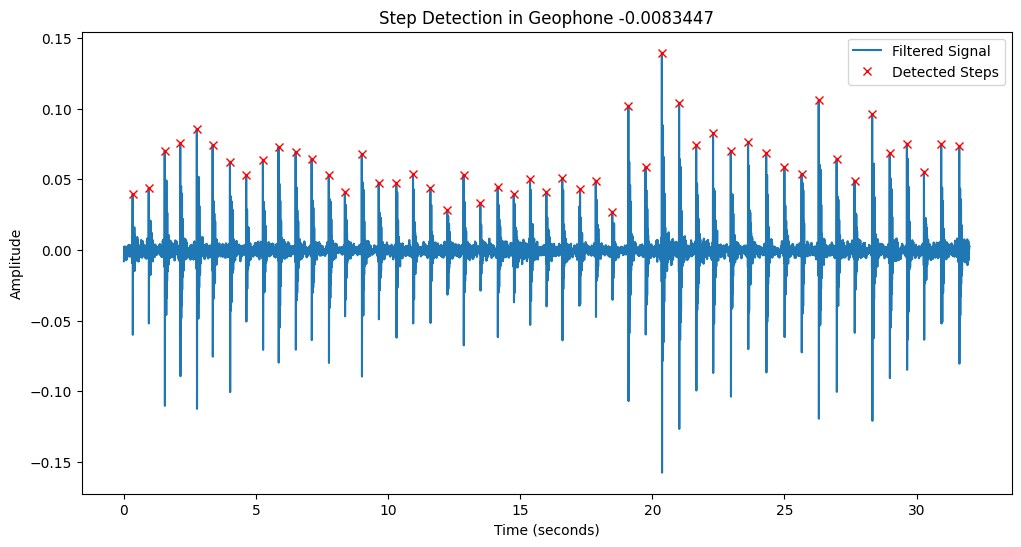

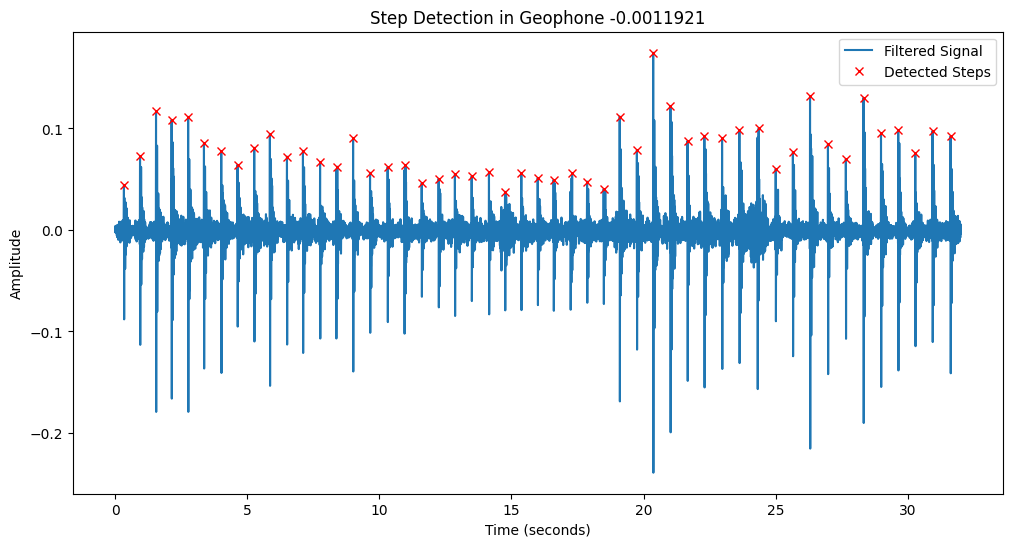

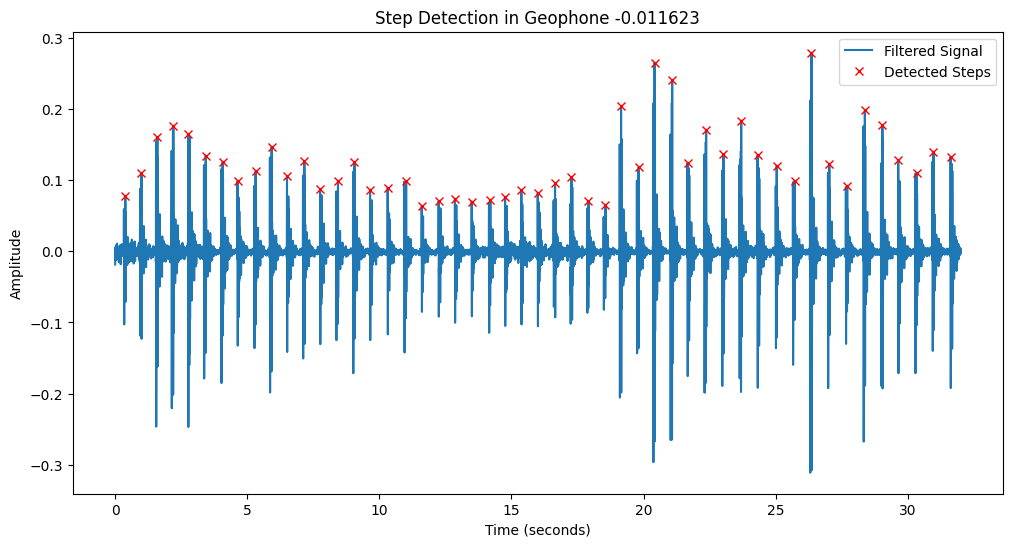

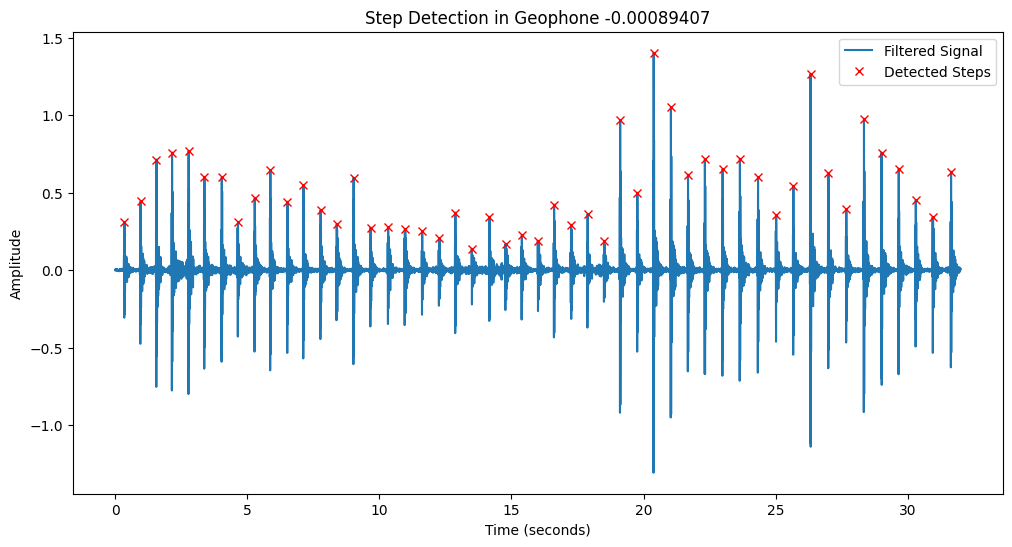

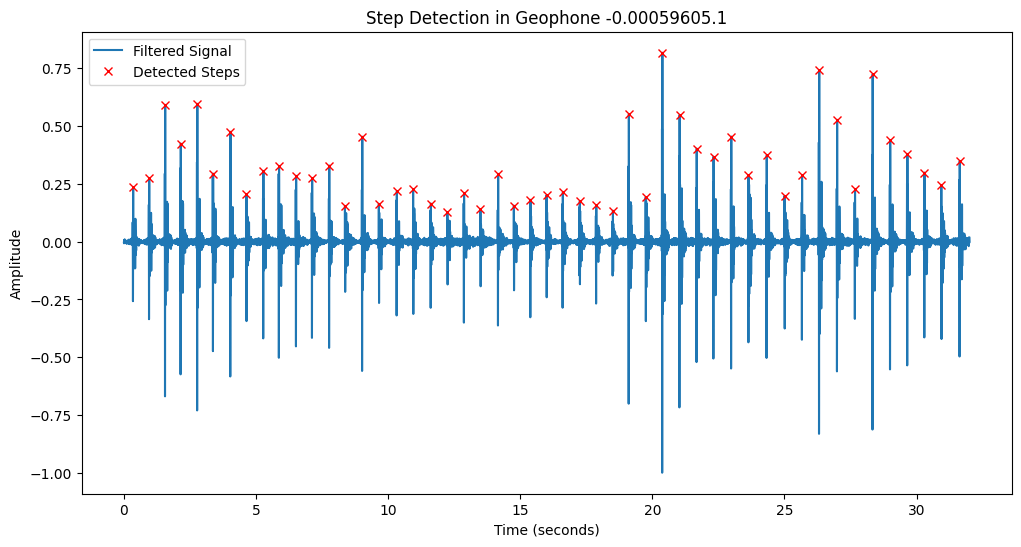

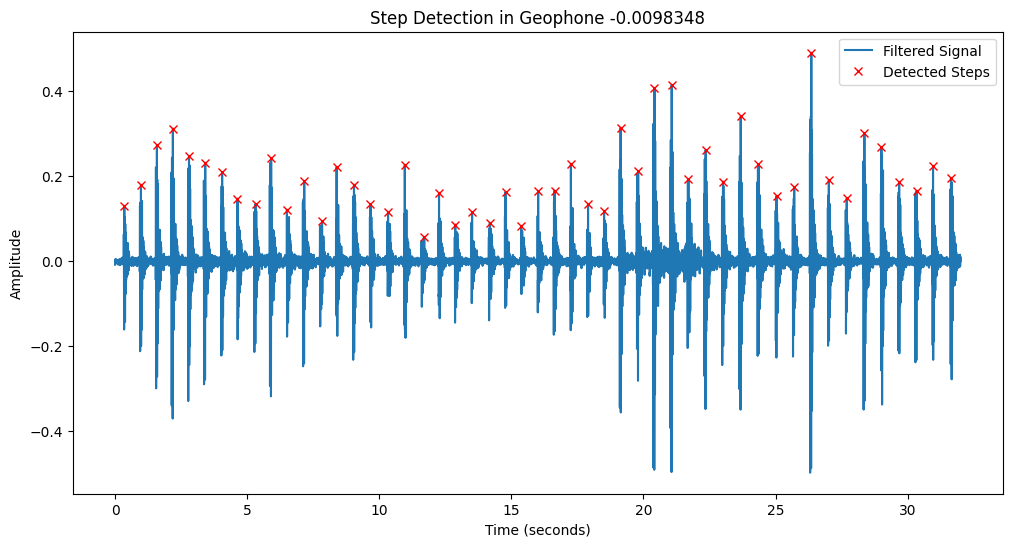

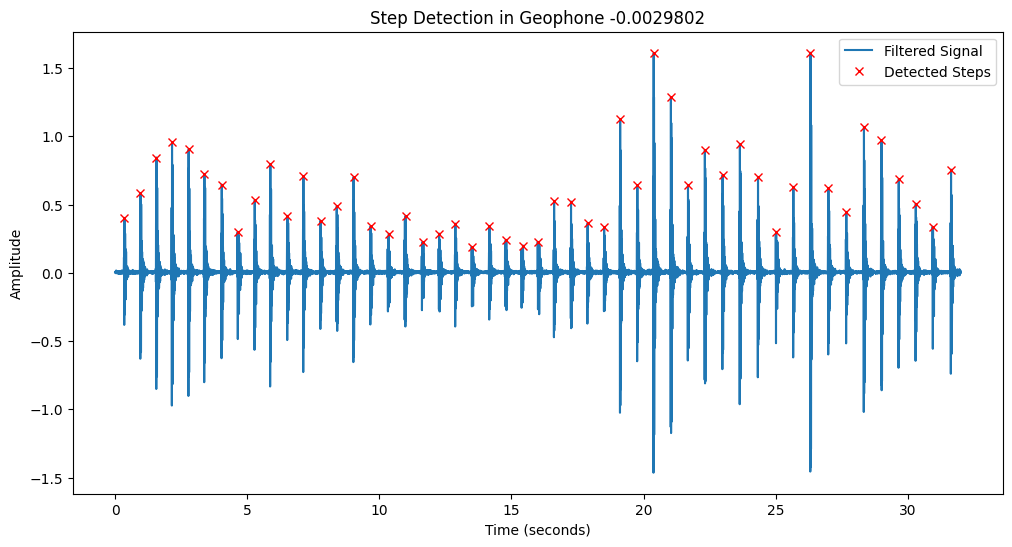

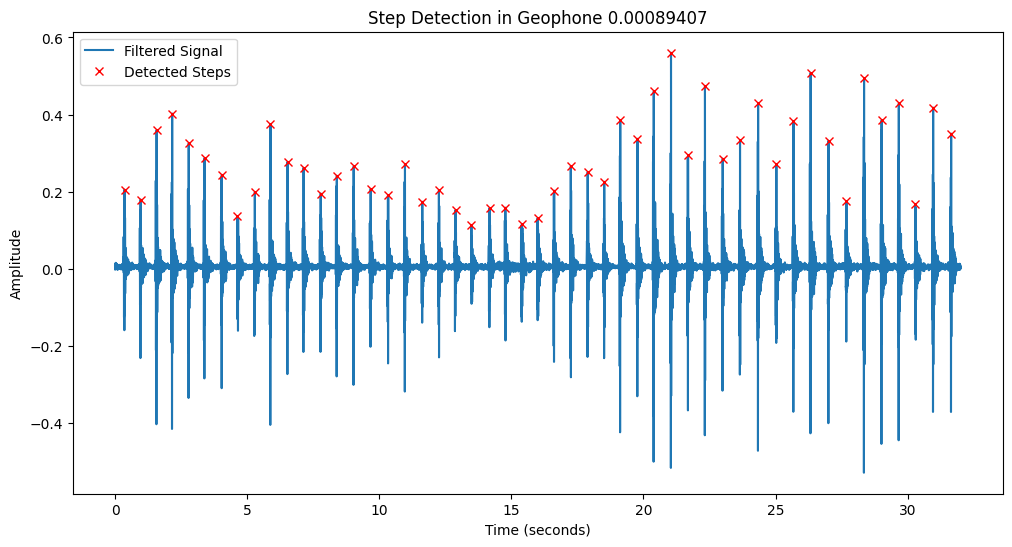

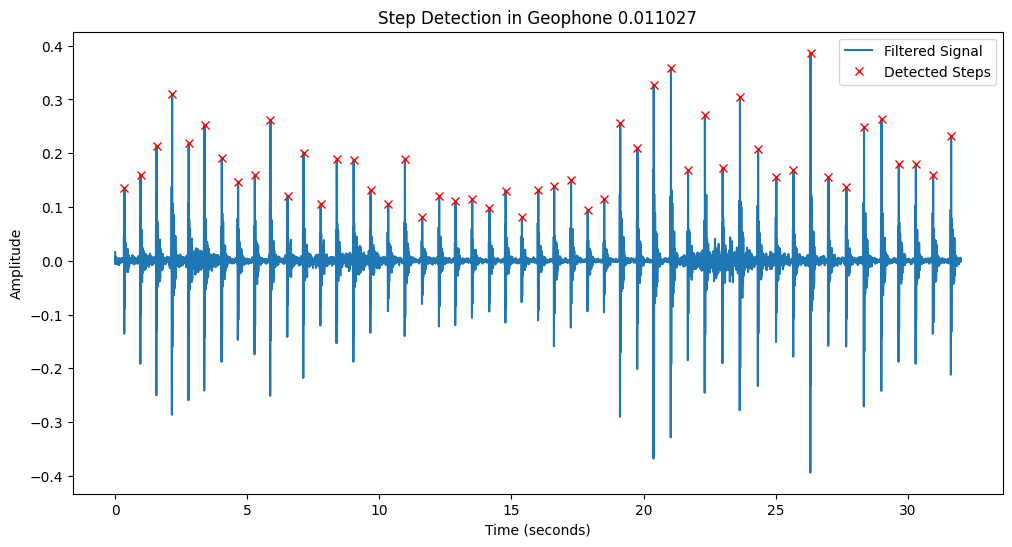

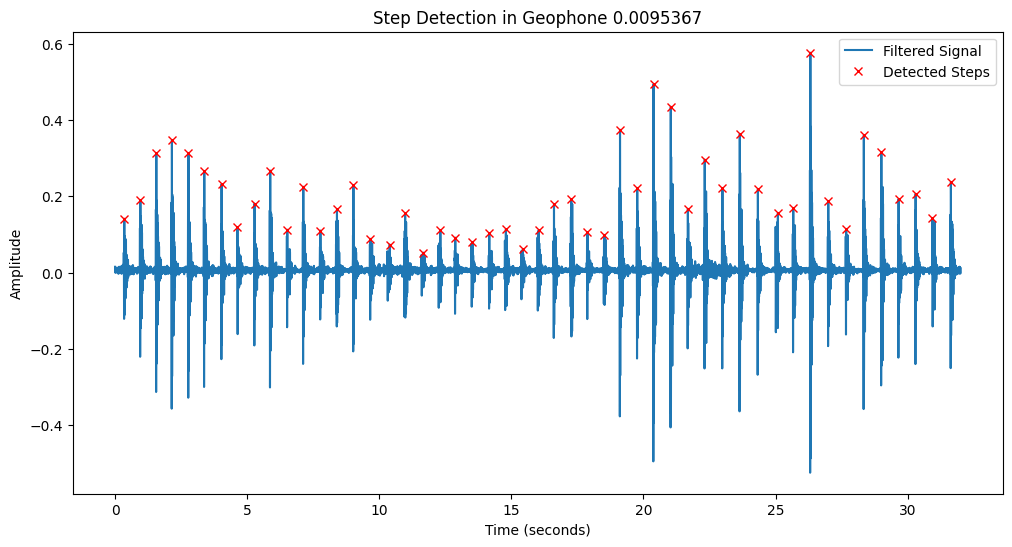

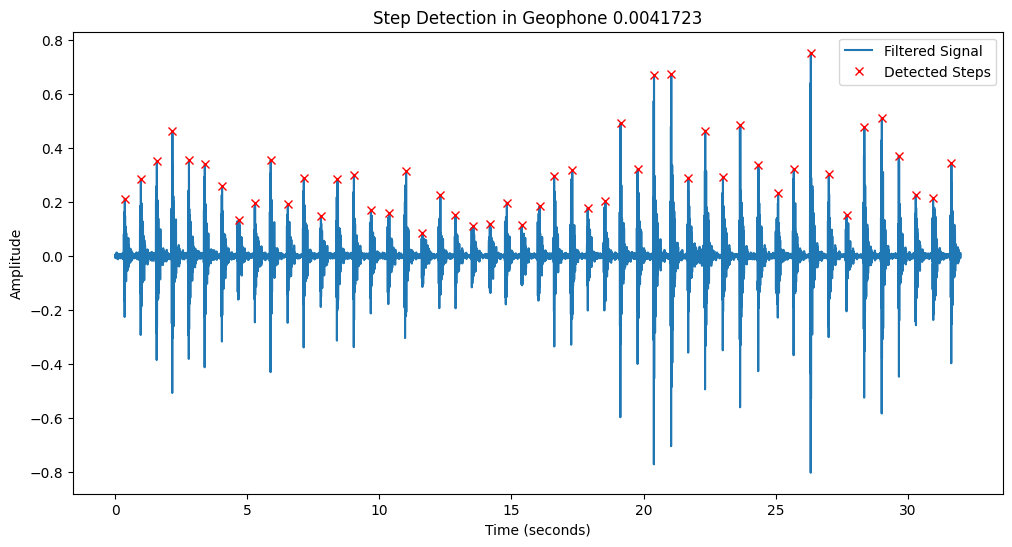

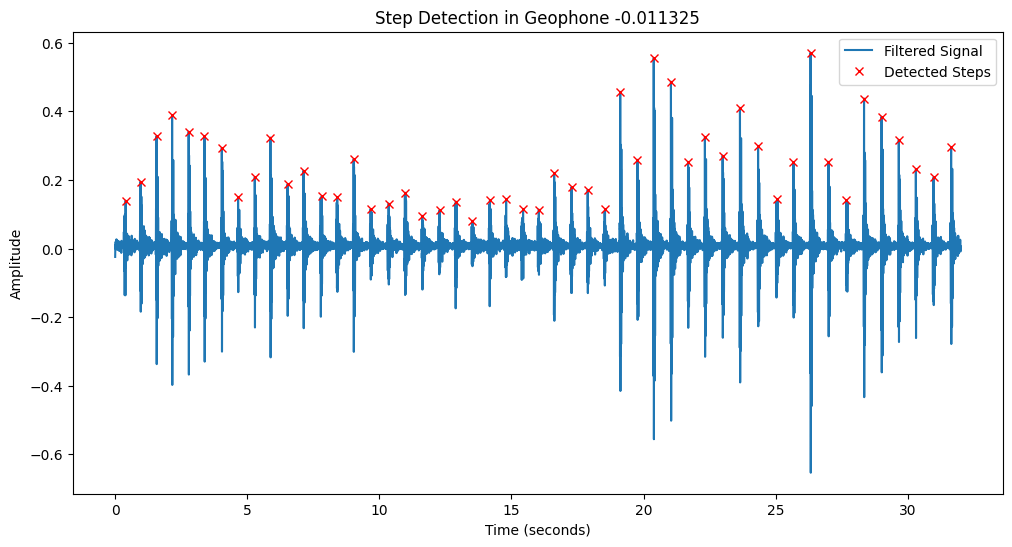

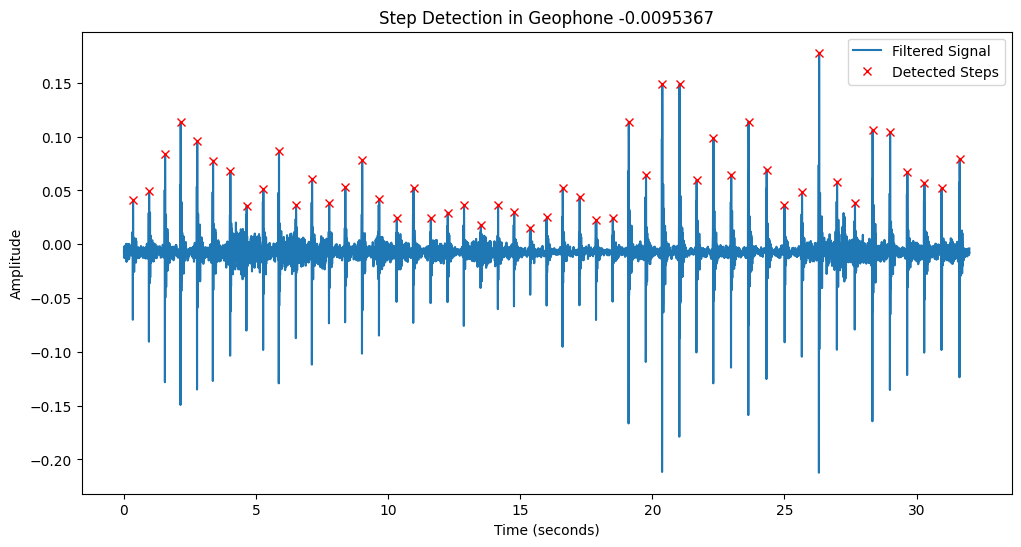

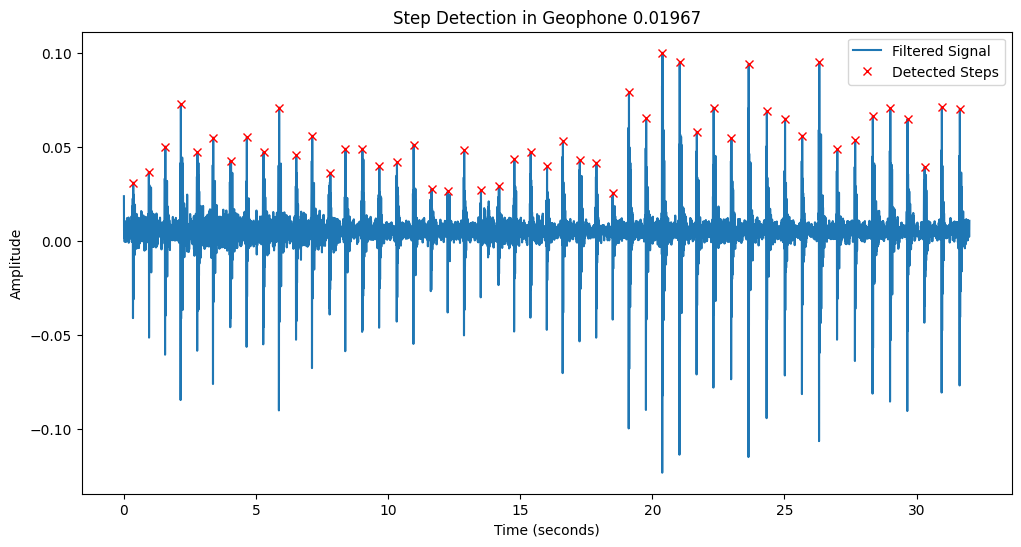

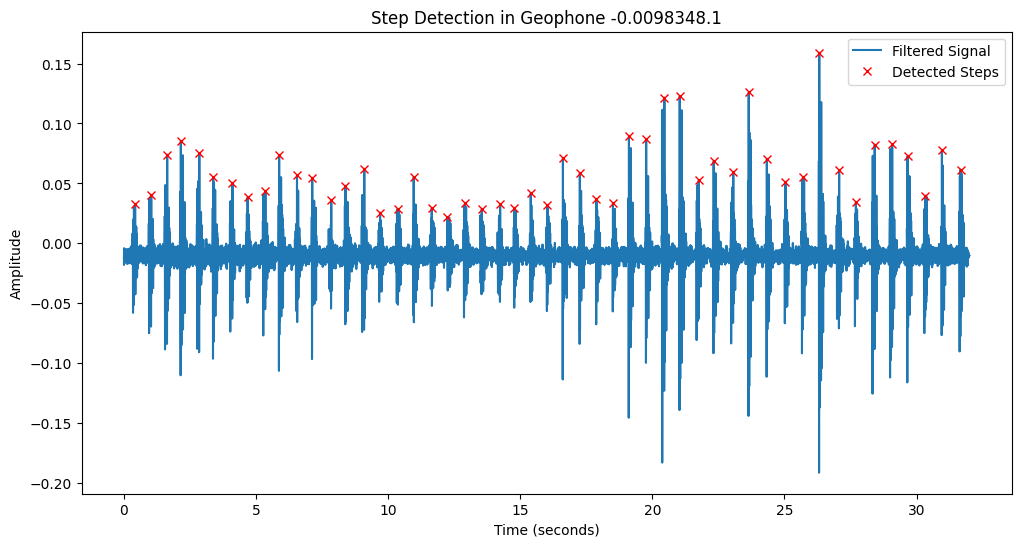

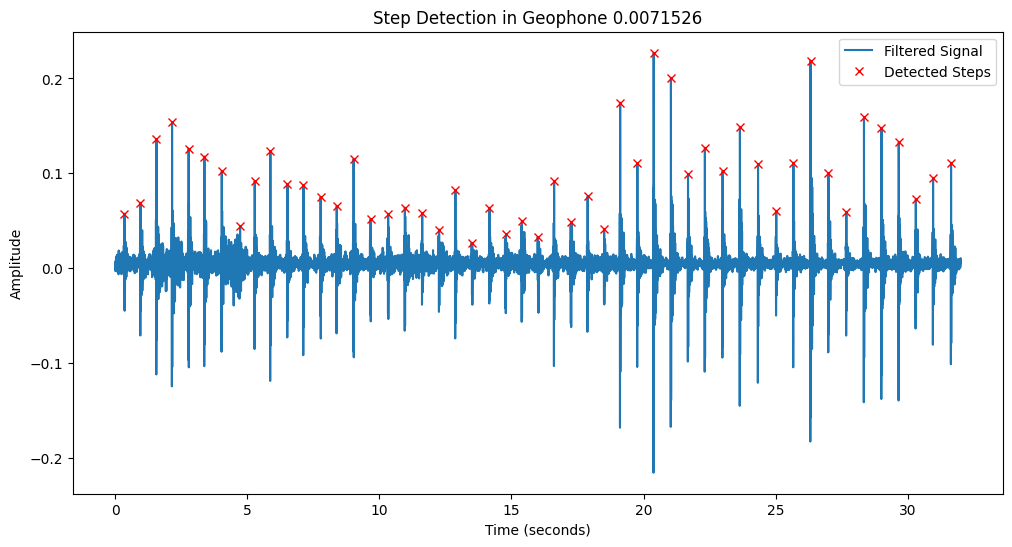

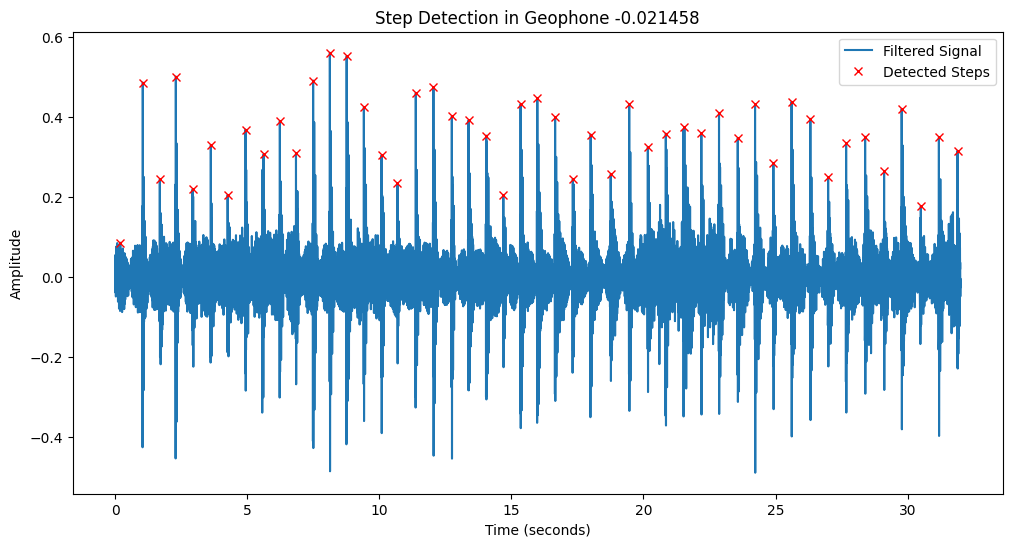

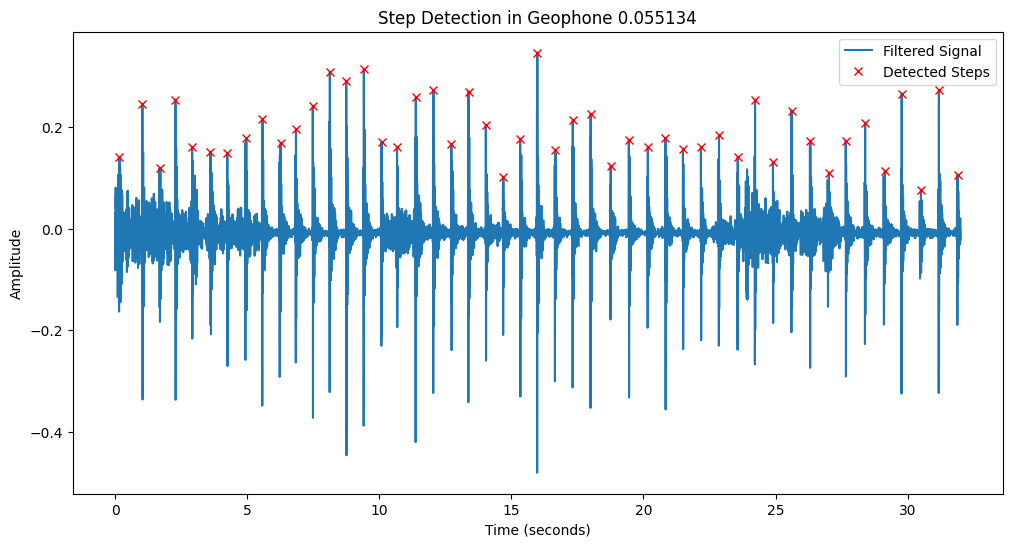

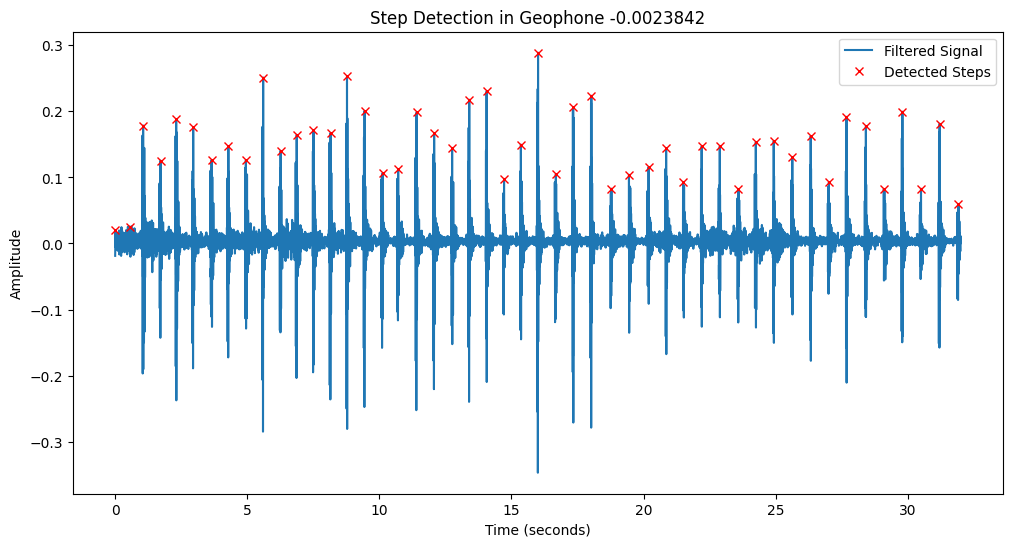

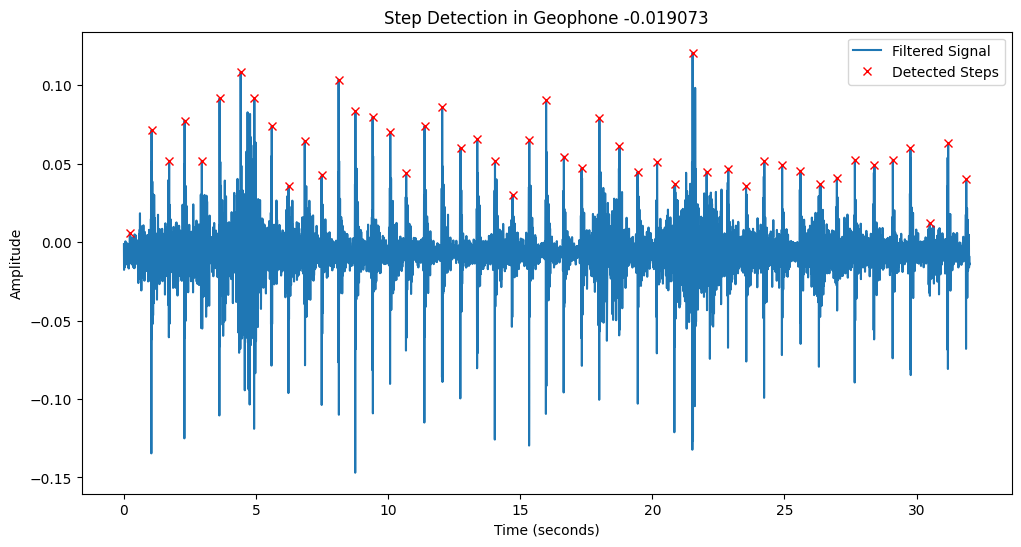

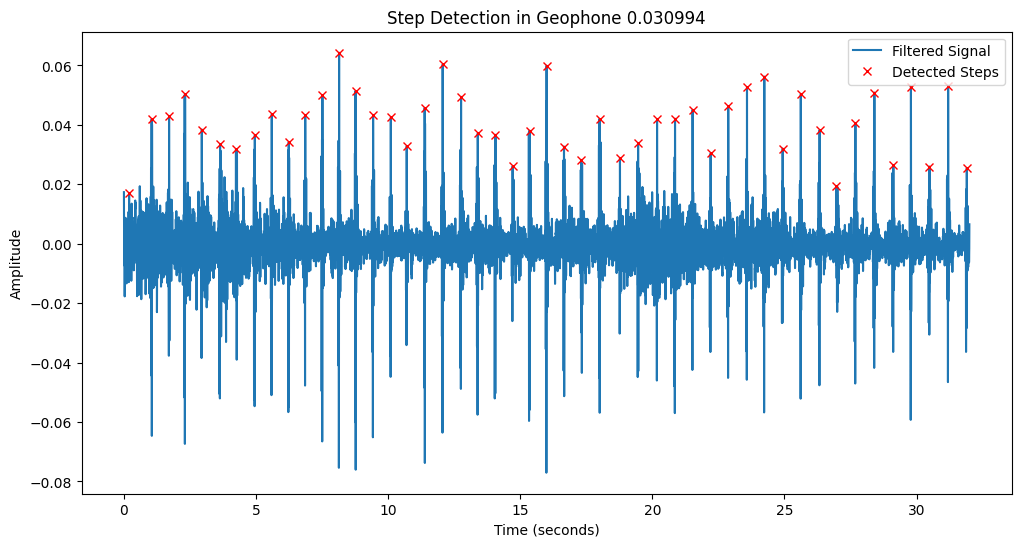

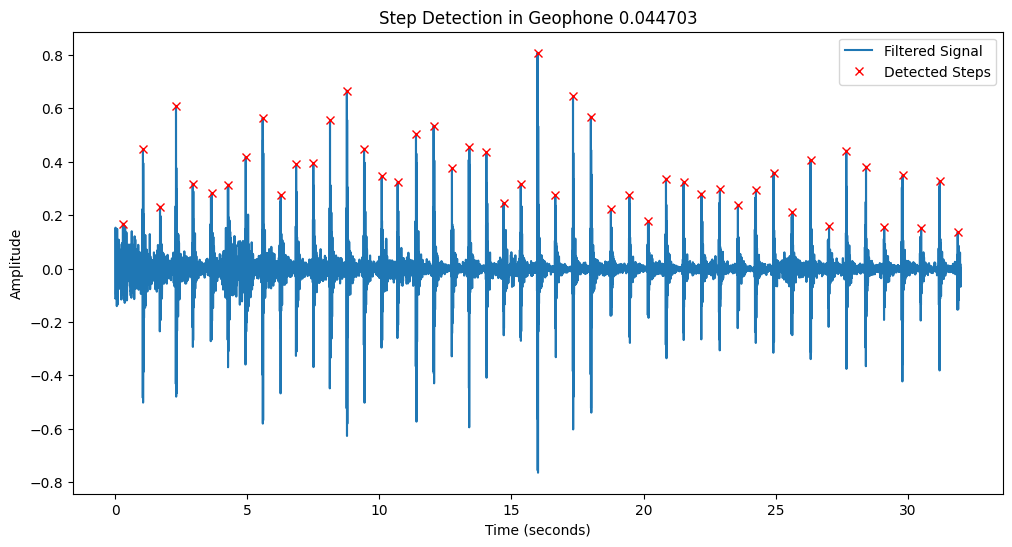

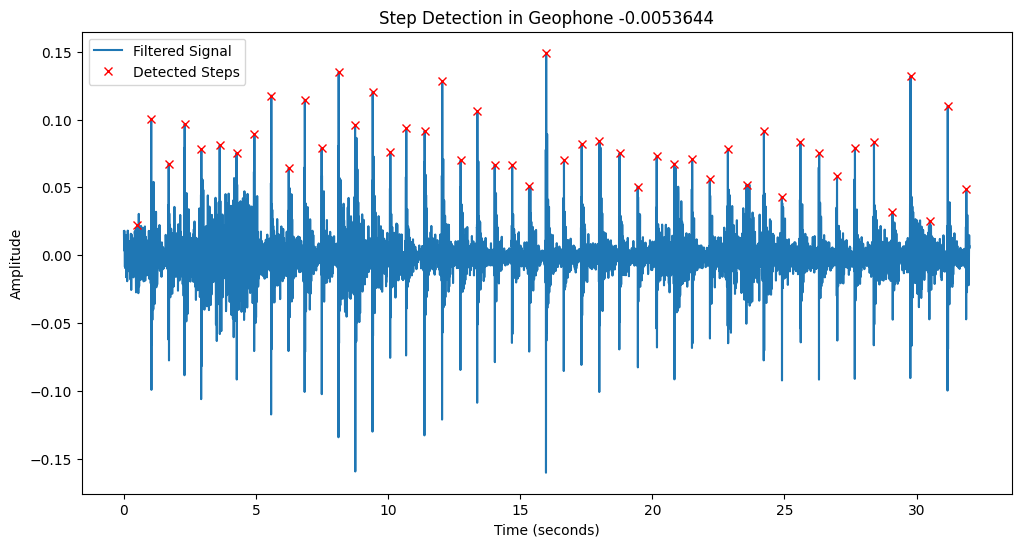

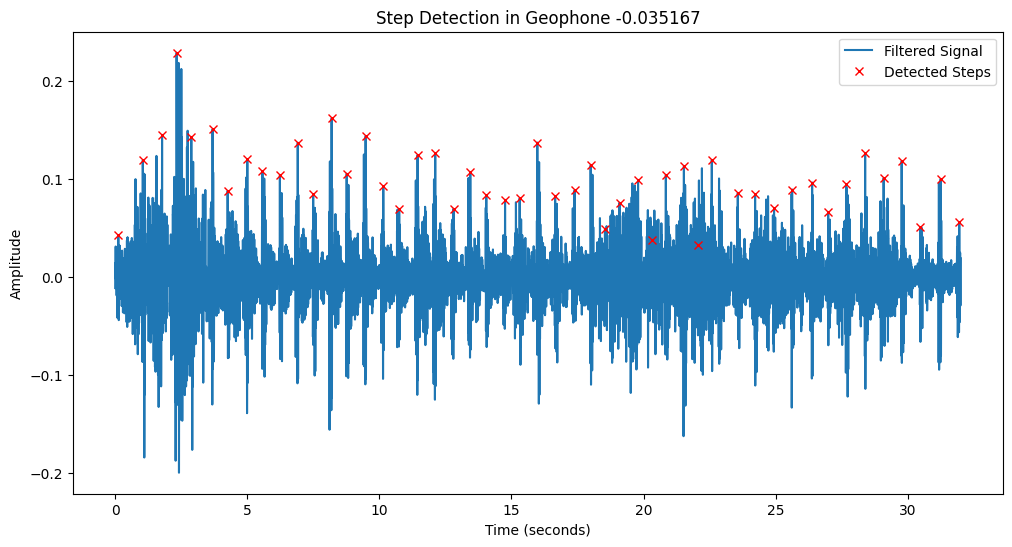

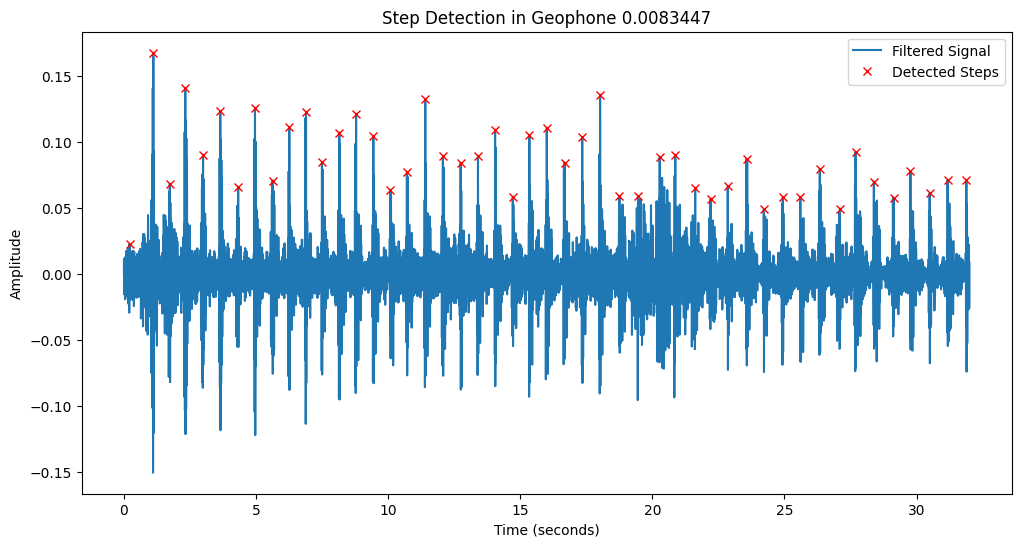

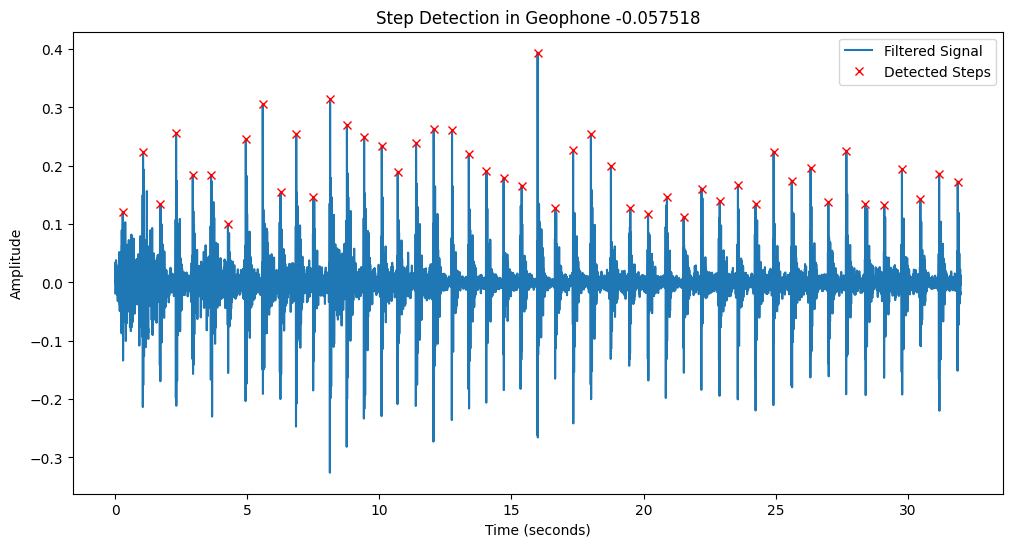

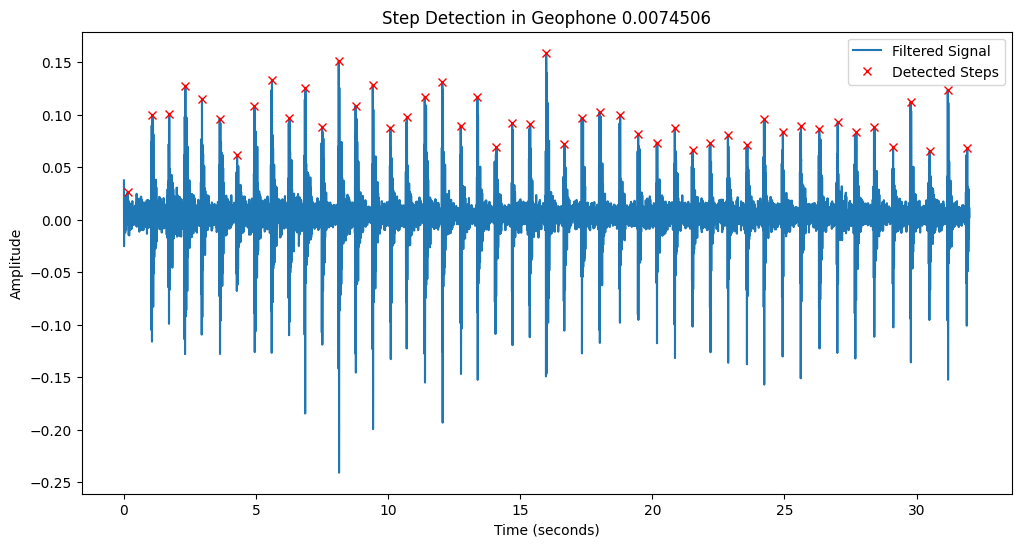

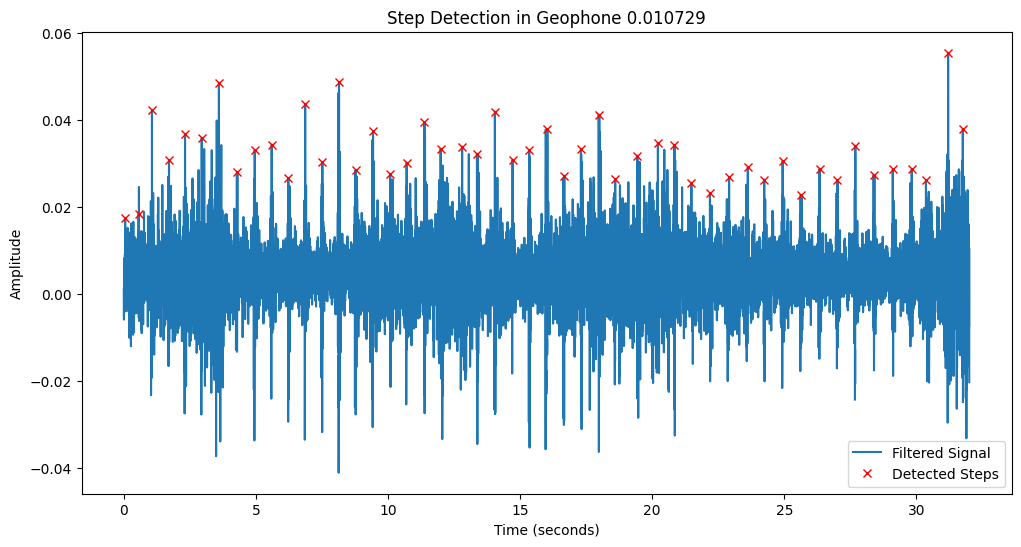

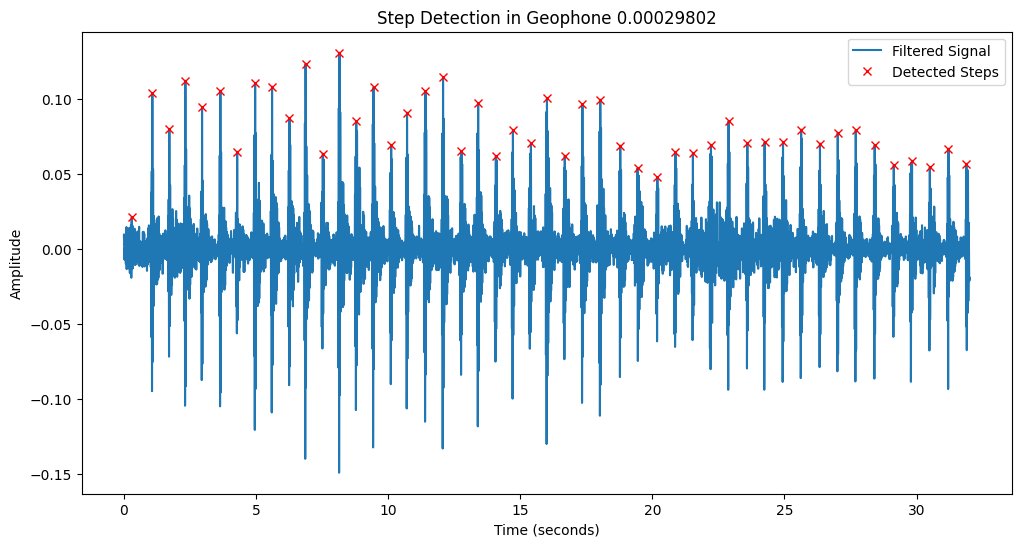

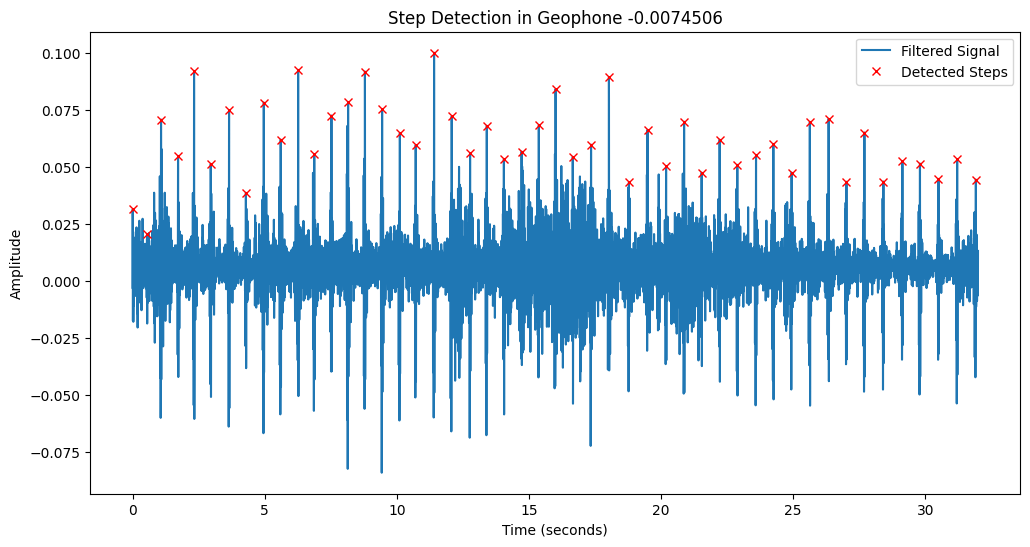

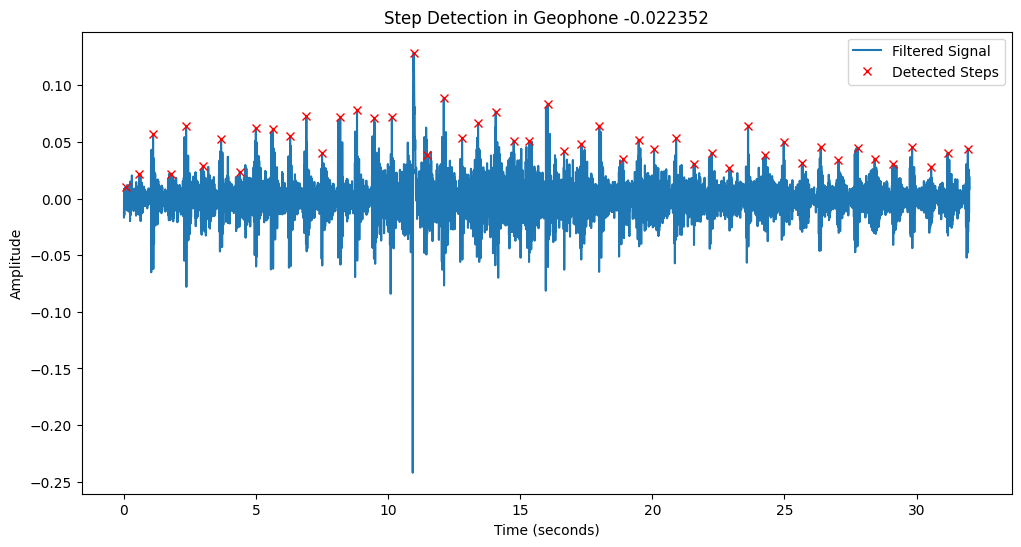

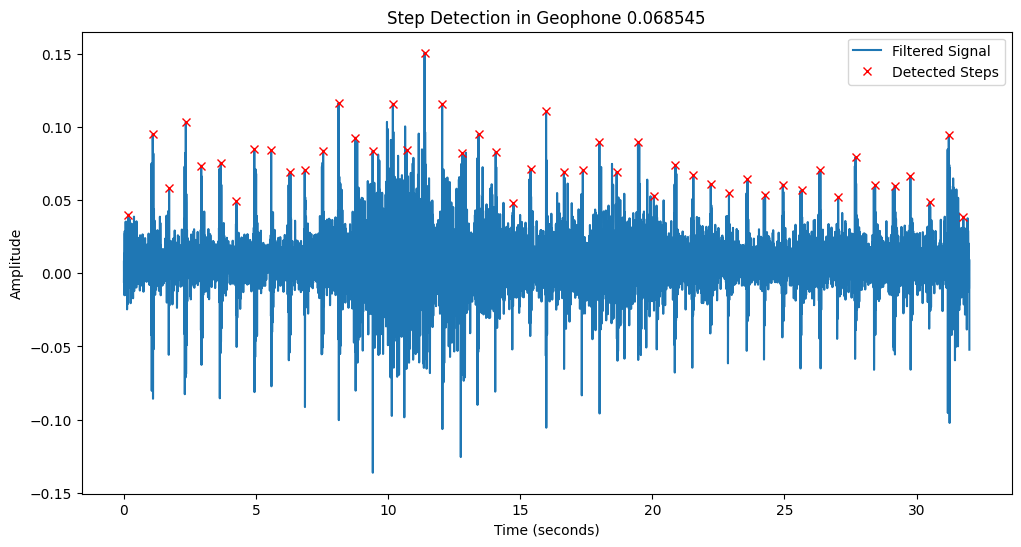

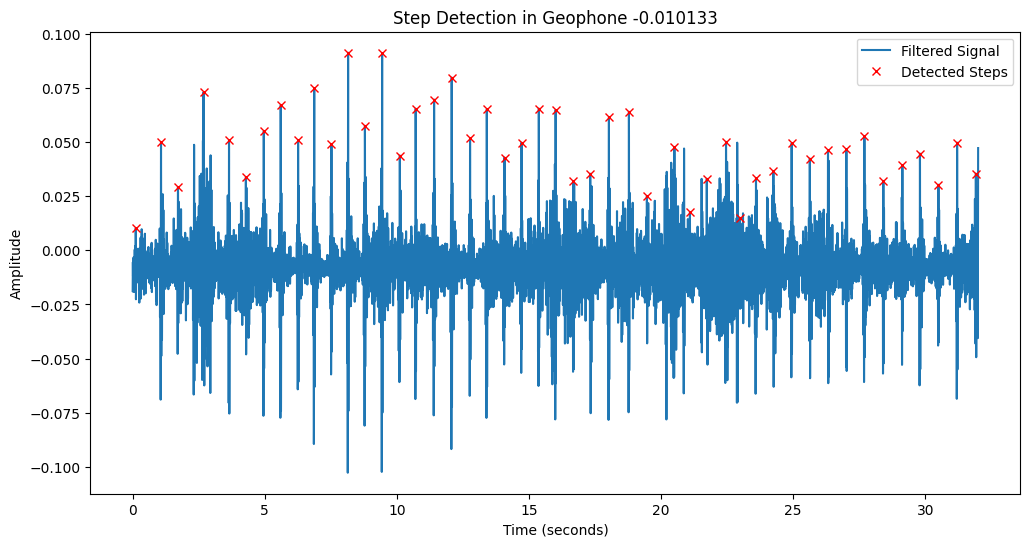

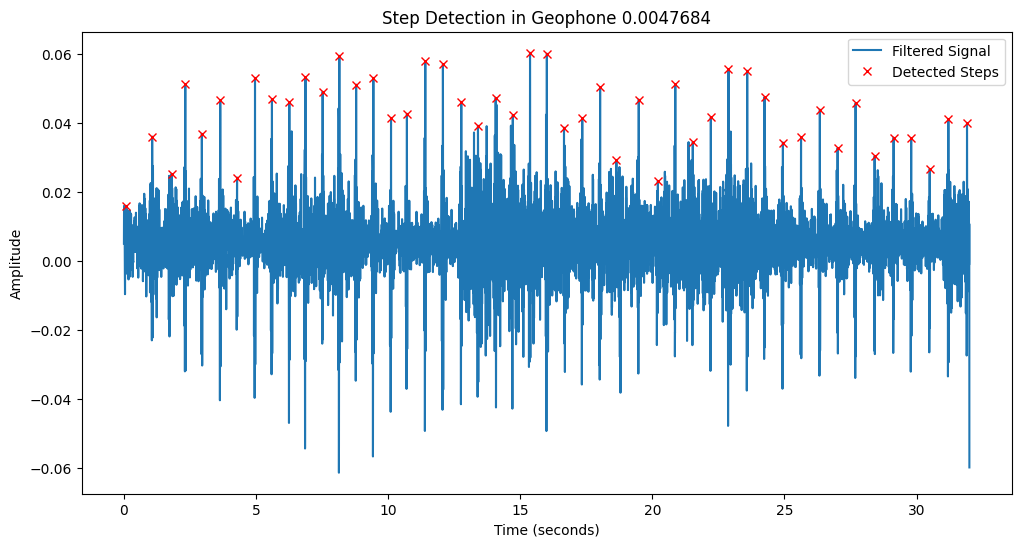

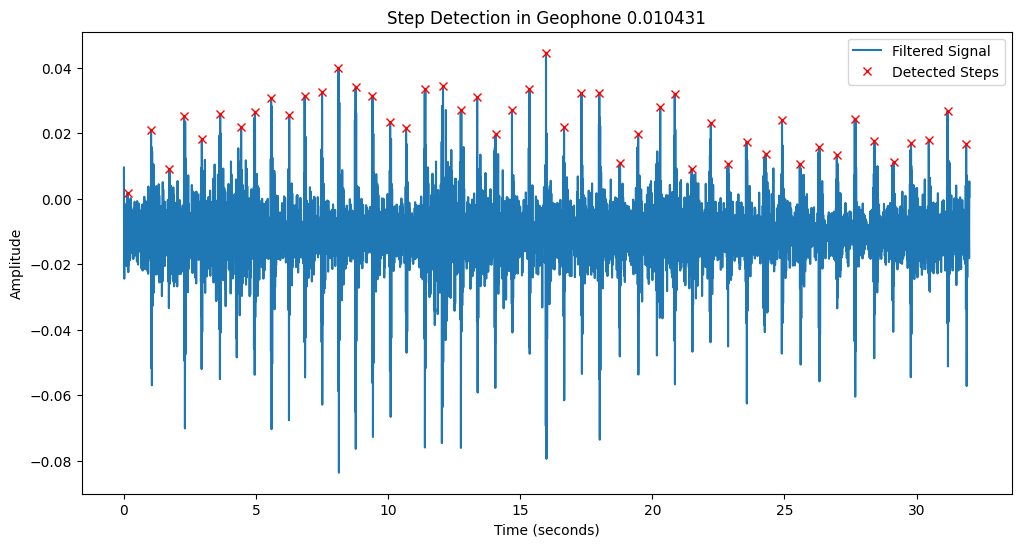

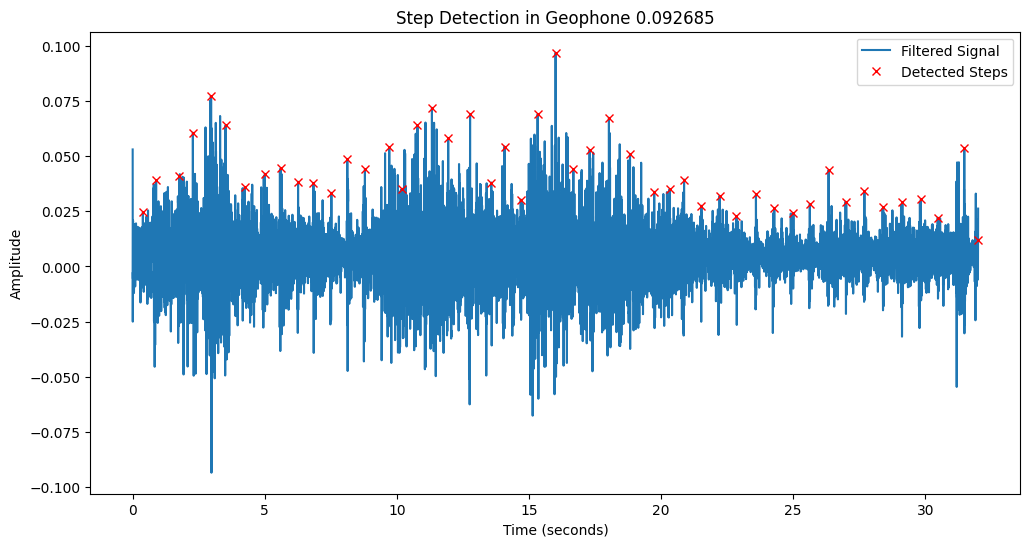

Shape of quiet_data: (27999, 39)
First few rows of quiet_data before processing:
       -0.00059605  -0.0044703  -0.0056624  -0.0083447  -0.0011921  -0.011623  \
32000    -0.004768    0.001192   -0.002682    0.011325   -0.006556   0.000000   
32001    -0.005066    0.005960   -0.005662    0.017285   -0.007153  -0.003576   
32002    -0.005960    0.005364   -0.006259    0.007749   -0.005960  -0.003576   
32003    -0.008047    0.007153   -0.006259   -0.004768    0.000894  -0.001788   
32004    -0.010133    0.009835   -0.006556   -0.011027    0.003278   0.001192   

       -0.00089407  -0.00059605.1  -0.0098348  -0.0029802  ...  0.0074506  \
32000     0.004172       0.002980   -0.001490   -0.002980  ...  -0.000298   
32001     0.004172      -0.013411   -0.001788   -0.002384  ...  -0.006259   
32002    -0.002086      -0.023246    0.000596    0.000596  ...  -0.015497   
32003    -0.009835      -0.003278    0.003576    0.000596  ...  -0.014007   
32004    -0.014901       0.010729    0.000000  

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import csv

# פונקציה לסינון בתדר נמוך
def low_pass_filter(data, cutoff_freq, sampling_rate):
    nyquist = 0.5 * sampling_rate
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(4, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# פרמטרים כלליים
samples_per_second = 1000  # דגימות לשנייה
time_range = 32 * samples_per_second  # 32 שניות עבור WALKING
quiet_start = time_range  # התחלת קטע השקט
cutoff_freq = 100  # תדר חיתוך לסינון בתדר נמוך
step_distance = 500  # מרחק מינימלי בין צעדים
step_height = 0  # גובה מינימלי של פיק

# *** חיתוך צעדים (WALKING) ***
step_windows = []

for col in data.columns[1:]:
    signal = data[col].iloc[:time_range].values
    filtered_signal = low_pass_filter(signal, cutoff_freq, samples_per_second)
    peaks, _ = find_peaks(filtered_signal, height=step_height, distance=step_distance)

    # יצירת חלונות סביב הפיקים
    for peak in peaks:
        start = max(0, peak - 150)
        end = min(len(filtered_signal), peak + 550)
        window = filtered_signal[start:end]
        if len(window) < 700:  # Padding לחלונות קצרים
            window = np.pad(window, (0, 700 - len(window)), 'constant')
        step_windows.append(window)

    # הצגת גרף של האות עם הפיקים
    time = np.arange(len(filtered_signal)) / samples_per_second
    plt.figure(figsize=(12, 6))
    plt.plot(time, filtered_signal, label='Filtered Signal')
    plt.plot([time[p] for p in peaks], [filtered_signal[p] for p in peaks], 'rx', label='Detected Steps')
    plt.title(f"Step Detection in Geophone {col}")
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.show()

# המרת חלונות WALKING למטריצה
walking_windows_matrix = np.array([window for window in step_windows if len(window) == 700])
walking_labels = np.array(["WALKING"] * len(walking_windows_matrix))

# *** חיתוך שקט (QUIET) ***
quiet_data = data.iloc[quiet_start:, 1:]  # כל הסנסורים

# בדיקה של הנתונים החתוכים
print(f"Shape of quiet_data: {quiet_data.shape}")
print(f"First few rows of quiet_data before processing:\n{quiet_data.head()}")

# טיפול ב-NaN אם קיים
if quiet_data.isna().any().any():
    print("Found NaN values in quiet_data, replacing with 0.")
    quiet_data = quiet_data.fillna(0)

quiet_windows = []
for col in quiet_data.columns:
    signal = quiet_data[col].values
    filtered_signal = low_pass_filter(signal, cutoff_freq, samples_per_second)

    # חלוקת קטע השקט לחלונות בגודל קבוע
    for i in range(0, len(filtered_signal), 700):
        window = filtered_signal[i:i + 700]
        if len(window) < 700:  # Padding לחלונות קצרים
            window = np.pad(window, (0, 700 - len(window)), 'constant')
        quiet_windows.append(window)

# המרת חלונות QUIET למטריצה
quiet_windows_matrix = np.array(quiet_windows)
quiet_labels = np.array(["QUIET"] * len(quiet_windows_matrix))

# *** שילוב כל החלונות ***
all_windows = np.vstack([walking_windows_matrix, quiet_windows_matrix])
all_labels = np.concatenate([walking_labels, quiet_labels])

# שמירת כל החלונות לקובץ CSV
output_file = "walking_and_quiet_windows.csv"
with open(output_file, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Window Index", "Sensor Data (Flattened)", "Label"])  # כותרת עמודות
    for i, (window, label) in enumerate(zip(all_windows, all_labels)):
        flattened_window = window.flatten()  # שטיחה של הנתונים
        writer.writerow([i, list(flattened_window), label])

print(f"Windows with labels saved to '{output_file}'")

# הדפסת מספר חלונות לכל קטגוריה
print(f"Number of WALKING Windows: {len(walking_windows_matrix)}")
print(f"Number of QUIET Windows: {len(quiet_windows_matrix)}")
print(f"Total Windows: {len(all_windows)}")


**CRNN**

In [7]:
####################
import librosa
import numpy as np
import scipy.stats
from scipy.signal import spectrogram
import pywt
from tqdm import tqdm
import time
import os

def extract_mfcc(signal, sr=1000, n_mfcc=13):
   return librosa.feature.mfcc(
      y=signal, 
      sr=sr,
      n_mfcc=n_mfcc,
      n_fft=512,
      hop_length=256
   )

def extract_chroma(signal, sr=1000):
   return librosa.feature.chroma_stft(
      y=signal,
      sr=sr,
      n_fft=512,
      hop_length=256 
   )

def monte_carlo_augmentation(signal, num_samples=20):
   mean = np.mean(signal)
   std = np.std(signal)
   samples = np.random.normal(mean, std, (num_samples, len(signal)))
   samples = np.abs(samples)
   samples = samples * (np.max(signal) / np.max(samples))
   return samples

def time_shift(signal, shift_range=100):
   shift = np.random.randint(-shift_range, shift_range)
   return np.roll(signal, shift)

def scale_amplitude(signal, scale_range=(0.8, 1.2)):
   scale = np.random.uniform(*scale_range)
   return signal * scale

def add_pink_noise(signal, noise_level=0.05):
   f = np.fft.fftfreq(len(signal))
   f = np.abs(f)
   f[0] = 1e-6
   pink_noise = np.random.normal(0, noise_level, len(signal)) / np.sqrt(f)
   return signal + pink_noise

def extract_enhanced_spectrogram(signal, fs=1000):
   nperseg = 32  
   noverlap = 28  
   f, t, Sxx = spectrogram(
      signal,
      fs=fs,
      nperseg=nperseg,
      noverlap=noverlap,
      window='hann',
      scaling='spectrum'
   )
   freq_mask = f <= 500
   return np.log10(np.maximum(Sxx[freq_mask], 1e-10)), f[freq_mask], t

def extract_time_frequency_features(signal):
   features = {
      'maximum': np.max(signal),
      'minimum': np.min(signal),
      'mean': np.mean(signal),
      'median': np.median(signal),
      'peak_to_peak': np.ptp(signal),
      'rectified_mean': np.mean(np.abs(signal)),
      'variance': np.var(signal),
      'std_dev': np.std(signal),
      'kurtosis': scipy.stats.kurtosis(signal),
      'skewness': scipy.stats.skew(signal),
      'rms': np.sqrt(np.mean(np.square(signal))),
      'mean_square': np.mean(np.square(signal)),
      'rms_amplitude': np.sqrt(np.mean(np.square(signal))),
      'center_frequency': np.average(np.fft.fftfreq(len(signal)), 
                                    weights=np.abs(np.fft.fft(signal))),
      'frequency_variance': np.var(np.abs(np.fft.fft(signal))),
      'frequency_std': np.std(np.abs(np.fft.fft(signal)))
   }
   
   peak = np.max(np.abs(signal))
   rms = np.sqrt(np.mean(np.square(signal)))
   features.update({
      'waveform_factor': rms / np.mean(np.abs(signal)),
      'peak_factor': peak / rms,
      'impulse_factor': peak / np.mean(np.abs(signal)),
      'margin_factor': peak / np.power(np.mean(np.abs(signal)), 2)
   })
   
   return features

def extract_spatial_energy_features(signal, sampling_rate=1000):
   wp = pywt.WaveletPacket(signal, 'db4', maxlevel=7)
   
   energy_bands = []
   for node in [node for node in wp.get_level(7)][:8]:
      band_energy = np.sum(node.data ** 2)
      total_energy = np.sum([np.sum(n.data ** 2) for n in wp.get_level(7)])
      energy_percentage = (band_energy / total_energy) * 100
      energy_bands.append(energy_percentage)
   
   return {'energy_bands': energy_bands}

# Data preparation
print("Loading and preparing data...")
start_time = time.time()

augmented_windows = []
augmented_labels = []
NUM_MC_SAMPLES = 20
NUM_AUGMENTATIONS_PER_WINDOW = 5

for window, label in tqdm(zip(all_windows, all_labels)):
   # Original window
   augmented_windows.append(window)
   augmented_labels.append(label)
   
   # Monte Carlo samples
   mc_samples = monte_carlo_augmentation(window, num_samples=NUM_MC_SAMPLES)
   for sample in mc_samples:
      augmented_windows.append(sample)
      augmented_labels.append(label)

   # Additional augmentations
   for _ in range(NUM_AUGMENTATIONS_PER_WINDOW):
      augmented_windows.extend([
         time_shift(window),
         scale_amplitude(window),
         add_pink_noise(window)
      ])
      augmented_labels.extend([label] * 3)

print(f"Augmentation time: {time.time() - start_time:.2f}s")

# Feature extraction
feature_start = time.time()
spectrograms = []
time_freq_features = []
spatial_energy_features = []
mfccs = []
chromas = []

for window in tqdm(augmented_windows):
   spec, _, _ = extract_enhanced_spectrogram(window)
   tf_feats = extract_time_frequency_features(window)
   spatial_feats = extract_spatial_energy_features(window)
   mfcc = extract_mfcc(window)
   chroma = extract_chroma(window)
   
   spectrograms.append(spec)
   time_freq_features.append(list(tf_feats.values()))
   spatial_energy_features.append(list(spatial_feats['energy_bands']))
   mfccs.append(mfcc)
   chromas.append(chroma)

# Convert to numpy arrays
spectrograms = np.array(spectrograms)
time_freq_features = np.array(time_freq_features)
spatial_energy_features = np.array(spatial_energy_features)
mfccs = np.array(mfccs)
chromas = np.array(chromas)

print(f"Feature extraction time: {time.time() - feature_start:.2f}s")
print(f"Total processing time: {time.time() - start_time:.2f}s")
print(f"Number of augmented samples: {len(augmented_windows)}")

Loading and preparing data...


3474it [00:01, 2383.80it/s]


Augmentation time: 1.46s


  0%|          | 0/125064 [00:00<?, ?it/s]d:\לימודים\פרויקט\.venv\Lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 125064/125064 [13:36<00:00, 153.20it/s]


Feature extraction time: 837.98s
Total processing time: 839.45s
Number of augmented samples: 125064


In [11]:
##############################
print("Loading raw signal windows...")
walking_labels = np.array(["WALKING"] * len(walking_windows_matrix))
quiet_labels = np.array(["QUIET"] * len(quiet_windows_matrix))
all_windows = np.vstack([walking_windows_matrix, quiet_windows_matrix])
all_labels = np.concatenate([walking_labels, quiet_labels])

augmented_windows = []
augmented_labels = []
NUM_MC_SAMPLES = 20
NUM_AUGMENTATIONS_PER_WINDOW = 5

for window, label in tqdm(zip(all_windows, all_labels)):
    # Original
    augmented_windows.append(window)
    augmented_labels.append(label)
    
    # Monte Carlo
    mc_samples = monte_carlo_augmentation(window, num_samples=NUM_MC_SAMPLES)
    for sample in mc_samples:
        augmented_windows.append(sample)
        augmented_labels.append(label)

    # Time shifted & scaled
    for _ in range(NUM_AUGMENTATIONS_PER_WINDOW):
        augmented_windows.extend([
            time_shift(window),
            scale_amplitude(window),
            add_pink_noise(window)
        ])
        augmented_labels.extend([label] * 3)

augmented_windows = np.array(augmented_windows)
augmented_labels = np.array(augmented_labels)

print("Data augmentation summary:")
print(f"Original examples: {len(all_windows)}")
print(f"Augmented total: {len(augmented_windows)}")
print(f"Walking examples: {np.sum(augmented_labels == 'WALKING')}")
print(f"Quiet examples: {np.sum(augmented_labels == 'QUIET')}")

Loading raw signal windows...


3474it [00:01, 2399.16it/s]


Data augmentation summary:
Original examples: 3474
Augmented total: 125064
Walking examples: 68904
Quiet examples: 56160


In [12]:
# הכנת התוויות
augmented_windows = np.array(augmented_windows)
augmented_labels = np.array(augmented_labels)

print(f"Number of augmented windows: {len(augmented_windows)}")
print(f"Number of augmented labels: {len(augmented_labels)}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(augmented_labels)

# המשך לחלקי הפיצ'רים והמודל...


Number of augmented windows: 125064
Number of augmented labels: 125064


In [13]:
#######################
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset

# חלוקת הנתונים לסטים של אימון, ולידציה ובדיקה
X_spec_train, X_spec_temp, X_mfcc_train, X_mfcc_temp, X_chroma_train, X_chroma_temp, X_tf_train, X_tf_temp, X_spatial_train, X_spatial_temp, y_train, y_temp = train_test_split(
    spectrograms, mfccs, chromas, time_freq_features, spatial_energy_features, y_encoded, 
    test_size=0.2, random_state=42, stratify=y_encoded
)

X_spec_val, X_spec_test, X_mfcc_val, X_mfcc_test, X_chroma_val, X_chroma_test, X_tf_val, X_tf_test, X_spatial_val, X_spatial_test, y_val, y_test = train_test_split(
    X_spec_temp, X_mfcc_temp, X_chroma_temp, X_tf_temp, X_spatial_temp, y_temp, 
    test_size=0.5, random_state=42, stratify=y_temp
)

# הדפסת גדלים של הסטים
print(f"Train set size: {len(X_spec_train)}")
print(f"Validation set size: {len(X_spec_val)}")
print(f"Test set size: {len(X_spec_test)}")

# המרה ל-Tensor
X_spec_train_tensor = torch.tensor(X_spec_train, dtype=torch.float32)
X_spec_val_tensor = torch.tensor(X_spec_val, dtype=torch.float32)
X_spec_test_tensor = torch.tensor(X_spec_test, dtype=torch.float32)

X_mfcc_train_tensor = torch.tensor(X_mfcc_train, dtype=torch.float32)
X_mfcc_val_tensor = torch.tensor(X_mfcc_val, dtype=torch.float32)
X_mfcc_test_tensor = torch.tensor(X_mfcc_test, dtype=torch.float32)

X_chroma_train_tensor = torch.tensor(X_chroma_train, dtype=torch.float32)
X_chroma_val_tensor = torch.tensor(X_chroma_val, dtype=torch.float32)
X_chroma_test_tensor = torch.tensor(X_chroma_test, dtype=torch.float32)

X_tf_train_tensor = torch.tensor(X_tf_train, dtype=torch.float32)
X_tf_val_tensor = torch.tensor(X_tf_val, dtype=torch.float32)
X_tf_test_tensor = torch.tensor(X_tf_test, dtype=torch.float32)

X_spatial_train_tensor = torch.tensor(X_spatial_train, dtype=torch.float32)
X_spatial_val_tensor = torch.tensor(X_spatial_val, dtype=torch.float32)
X_spatial_test_tensor = torch.tensor(X_spatial_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# יצירת TensorDataset
train_dataset = TensorDataset(
    X_spec_train_tensor, X_mfcc_train_tensor, X_chroma_train_tensor, 
    X_tf_train_tensor, X_spatial_train_tensor, y_train_tensor
)
val_dataset = TensorDataset(
    X_spec_val_tensor, X_mfcc_val_tensor, X_chroma_val_tensor, 
    X_tf_val_tensor, X_spatial_val_tensor, y_val_tensor
)
test_dataset = TensorDataset(
    X_spec_test_tensor, X_mfcc_test_tensor, X_chroma_test_tensor, 
    X_tf_test_tensor, X_spatial_test_tensor, y_test_tensor
)

# יצירת DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Train set size: 100051
Validation set size: 12506
Test set size: 12507


In [80]:
# 1. הכנת התוויות
from torch.utils.data import Dataset, DataLoader
y_encoded = label_encoder.fit_transform(augmented_labels)

# 2. חלוקת הנתונים
(spec_train, spec_temp, mfcc_train, mfcc_temp, chroma_train, chroma_temp,
 tf_train, tf_temp, spatial_train, spatial_temp,
 y_train, y_temp) = train_test_split(
    spectrograms, mfccs, chromas, time_freq_features, spatial_energy_features, y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

(spec_val, spec_test, mfcc_val, mfcc_test, chroma_val, chroma_test,
 tf_val, tf_test, spatial_val, spatial_test,
 y_val, y_test) = train_test_split(
    spec_temp, mfcc_temp, chroma_temp, tf_temp, spatial_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

# 3. יצירת Dataset
class WalkingDataset(Dataset):
    def __init__(self, spec, mfcc, chroma, tf, spatial, labels):
        self.spec = torch.FloatTensor(spec)
        self.mfcc = torch.FloatTensor(mfcc)
        self.chroma = torch.FloatTensor(chroma)
        self.tf = torch.FloatTensor(tf)
        self.spatial = torch.FloatTensor(spatial)
        self.labels = torch.LongTensor(labels)
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (self.spec[idx], self.mfcc[idx], self.chroma[idx],
                self.tf[idx], self.spatial[idx], self.labels[idx])

# 4. יצירת DataLoaders
train_dataset = WalkingDataset(spec_train, mfcc_train, chroma_train,
                              tf_train, spatial_train, y_train)
val_dataset = WalkingDataset(spec_val, mfcc_val, chroma_val,
                            tf_val, spatial_val, y_val)
test_dataset = WalkingDataset(spec_test, mfcc_test, chroma_test,
                             tf_test, spatial_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)
print("train size :", len(train_loader), "val size", len(val_loader), "test size", len(test_loader))
print("size of train_dataset", len(train_dataset), "size of val_dataset", len(val_dataset), "size of test_dataset", len(test_dataset))

train size : 1564 val size 196 test size 196
size of train_dataset 100051 size of val_dataset 12506 size of test_dataset 12507


**CRNNModel**

In [110]:
class DualStreamModel(nn.Module):
    def __init__(self, input_channels, hidden_size=256, output_size=2, num_cnn_layers=3,
                 initial_filters=32, kernel_size=3, dropout_cnn=0.2,
                 gru_layers=2, gru_dropout=0.3, bidirectional=True,
                 tf_feature_dim=26, spatial_feature_dim=8):
        super(DualStreamModel, self).__init__()
        
        self.spec_initial_pool = nn.AdaptiveAvgPool2d((32, 32))
        self.mfcc_initial_pool = nn.AdaptiveAvgPool2d((32, 32))
        self.chroma_initial_pool = nn.AdaptiveAvgPool2d((32, 32))

        self.cnn_spec = self._make_cnn_layers(input_channels, initial_filters, num_cnn_layers, kernel_size, dropout_cnn)
        self.cnn_mfcc = self._make_cnn_layers(input_channels, initial_filters, num_cnn_layers, kernel_size, dropout_cnn)
        self.cnn_chroma = self._make_cnn_layers(input_channels, initial_filters, num_cnn_layers, kernel_size, dropout_cnn)

        cnn_output_size = self._calculate_cnn_output_size(initial_filters, num_cnn_layers)
        self.cnn_output_size = cnn_output_size * 3
        self.tf_feature_dim = tf_feature_dim
        self.spatial_feature_dim = spatial_feature_dim
        self.total_feature_size = self.cnn_output_size + self.tf_feature_dim + self.spatial_feature_dim

        self.gru = nn.GRU(
            input_size=self.total_feature_size,
            hidden_size=hidden_size,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=gru_dropout
        )

        self.self_attention = SelfAttention(hidden_size * 2 if bidirectional else hidden_size)

        fc_input_size = hidden_size * 2 if bidirectional else hidden_size
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_cnn),
            nn.Linear(hidden_size, output_size)
        )

    def _make_cnn_layers(self, in_channels, initial_filters, num_layers, kernel_size, dropout):
        layers = []
        channels = in_channels
        
        for i in range(num_layers):
            out_channels = initial_filters * (2 ** i)
            layers.extend([
                nn.Conv2d(channels, out_channels, kernel_size, padding=kernel_size//2),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Dropout2d(dropout)
            ])
            channels = out_channels
            
        return nn.Sequential(*layers)

    def _calculate_cnn_output_size(self, initial_filters, num_layers):
        size = 32
        for i in range(num_layers):
            size = size // 2
        final_channels = initial_filters * (2 ** (num_layers - 1))
        return size * size * final_channels

    def forward(self, spec_features, mfcc_features, chroma_features, tf_features, spatial_features):
        spec_features = self.spec_initial_pool(spec_features)
        mfcc_features = self.mfcc_initial_pool(mfcc_features)
        chroma_features = self.chroma_initial_pool(chroma_features)

        spec_out = self.cnn_spec(spec_features)
        mfcc_out = self.cnn_mfcc(mfcc_features)
        chroma_out = self.cnn_chroma(chroma_features)

        batch_size = spec_features.size(0)
        spec_out = spec_out.view(batch_size, -1)
        mfcc_out = mfcc_out.view(batch_size, -1)
        chroma_out = chroma_out.view(batch_size, -1)
        
        cnn_combined = torch.cat((spec_out, mfcc_out, chroma_out), dim=1)
        combined_features = torch.cat((cnn_combined, tf_features, spatial_features), dim=1)
        combined_features = combined_features.unsqueeze(1)

        rnn_out, _ = self.gru(combined_features)
        out = self.self_attention(rnn_out)
        
        return self.fc(out)

class SelfAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )
    
    def forward(self, x):
        attention_weights = F.softmax(self.attention(x), dim=1)
        return torch.sum(attention_weights * x, dim=1)


**Analizer**

In [106]:
# הוספת הספריות הנדרשות
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import seaborn as sns

class ModelAnalyzer:
    def __init__(self):
        self.training_history = {
            'epoch': [],
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'learning_rate': []
        }
        
    def add_epoch_stats(self, epoch, train_loss, train_acc, val_loss, val_acc, lr):
        self.training_history['epoch'].append(epoch)
        self.training_history['train_loss'].append(train_loss)
        self.training_history['train_acc'].append(train_acc)
        self.training_history['val_loss'].append(val_loss)
        self.training_history['val_acc'].append(val_acc)
        self.training_history['learning_rate'].append(lr)
    
    def plot_training_history(self):
        plt.figure(figsize=(15, 5))
        
        # Plot Loss
        plt.subplot(1, 2, 1)
        plt.plot(self.training_history['epoch'], self.training_history['train_loss'], label='Train Loss')
        plt.plot(self.training_history['epoch'], self.training_history['val_loss'], label='Validation Loss')
        plt.title('Loss Over Time')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        
        # Plot Accuracy
        plt.subplot(1, 2, 2)
        plt.plot(self.training_history['epoch'], self.training_history['train_acc'], label='Train Accuracy')
        plt.plot(self.training_history['epoch'], self.training_history['val_acc'], label='Validation Accuracy')
        plt.title('Accuracy Over Time')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        
        plt.tight_layout()
        plt.show()

    def plot_confusion_matrix(self, y_true, y_pred, class_names=['WALKING', 'QUIET']):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=class_names, yticklabels=class_names)
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
        
    def plot_roc_curves(self, y_true, y_prob, class_names):
        plt.figure(figsize=(10, 8))
        for i in range(len(class_names)):
            fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_prob[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
        
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves')
        plt.legend()
        plt.show()
    def reset(self):
        """
        Reset the training history to start fresh.
        """
        self.training_history = {
            'epoch': [],
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'learning_rate': []
        }

##########################

#######################

**Train**

Epoch [1/150] Train Loss: 0.3183 Train Acc: 0.8581 Val Loss: 0.2484 Val Acc: 0.8944 LR: 0.001000
Epoch [2/150] Train Loss: 0.2717 Train Acc: 0.8833 Val Loss: 0.2300 Val Acc: 0.9076 LR: 0.001000
Epoch [3/150] Train Loss: 0.2614 Train Acc: 0.8893 Val Loss: 0.2430 Val Acc: 0.8988 LR: 0.001000
Epoch [4/150] Train Loss: 0.2541 Train Acc: 0.8948 Val Loss: 0.2227 Val Acc: 0.9101 LR: 0.001000
Epoch [5/150] Train Loss: 0.2494 Train Acc: 0.8959 Val Loss: 0.2256 Val Acc: 0.9126 LR: 0.001000
Epoch [6/150] Train Loss: 0.2494 Train Acc: 0.8960 Val Loss: 0.2261 Val Acc: 0.9089 LR: 0.001000
Epoch [7/150] Train Loss: 0.2464 Train Acc: 0.8986 Val Loss: 0.2197 Val Acc: 0.9136 LR: 0.001000
Epoch [8/150] Train Loss: 0.2411 Train Acc: 0.9015 Val Loss: 0.2247 Val Acc: 0.9096 LR: 0.001000
Epoch [9/150] Train Loss: 0.2416 Train Acc: 0.9013 Val Loss: 0.2206 Val Acc: 0.9108 LR: 0.001000
Epoch [10/150] Train Loss: 0.2399 Train Acc: 0.9014 Val Loss: 0.2196 Val Acc: 0.9124 LR: 0.001000
Epoch [11/150] Train Loss: 0.

C:\Users\lidor\AppData\Local\Temp\ipykernel_10472\1263022796.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))



Performance Metrics:
--------------------------------------------------
Test Accuracy:       92.34%
Validation Accuracy: 92.00%
Training Accuracy:   92.16%
--------------------------------------------------


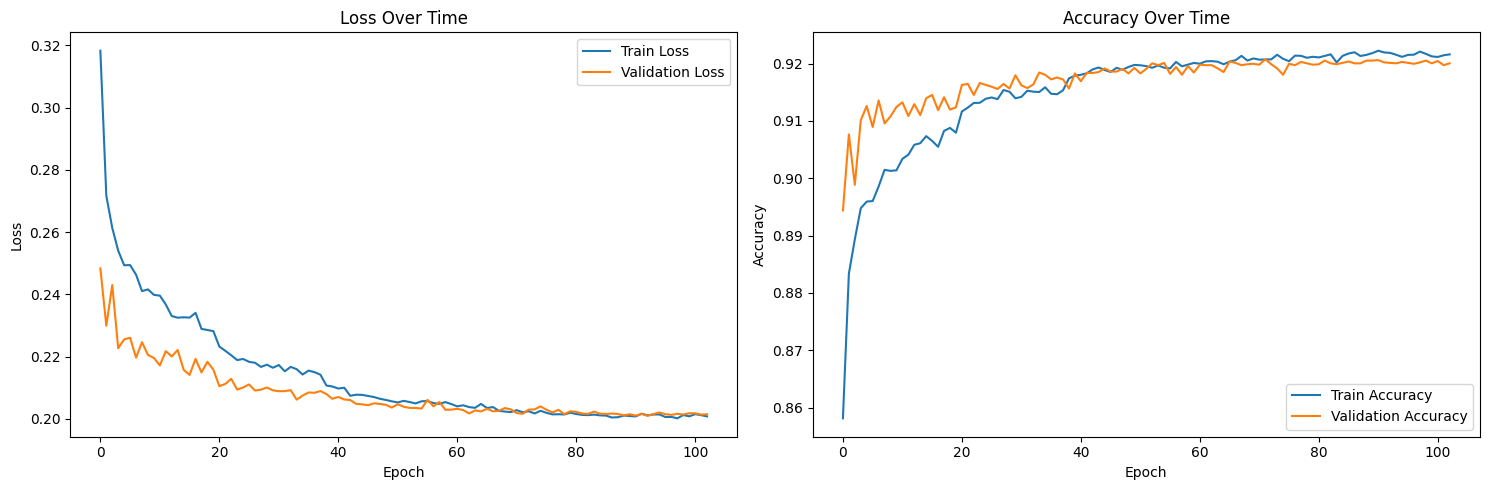

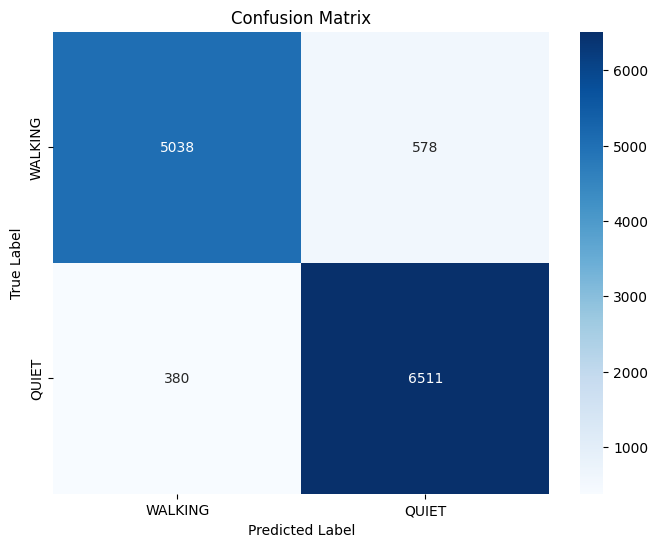

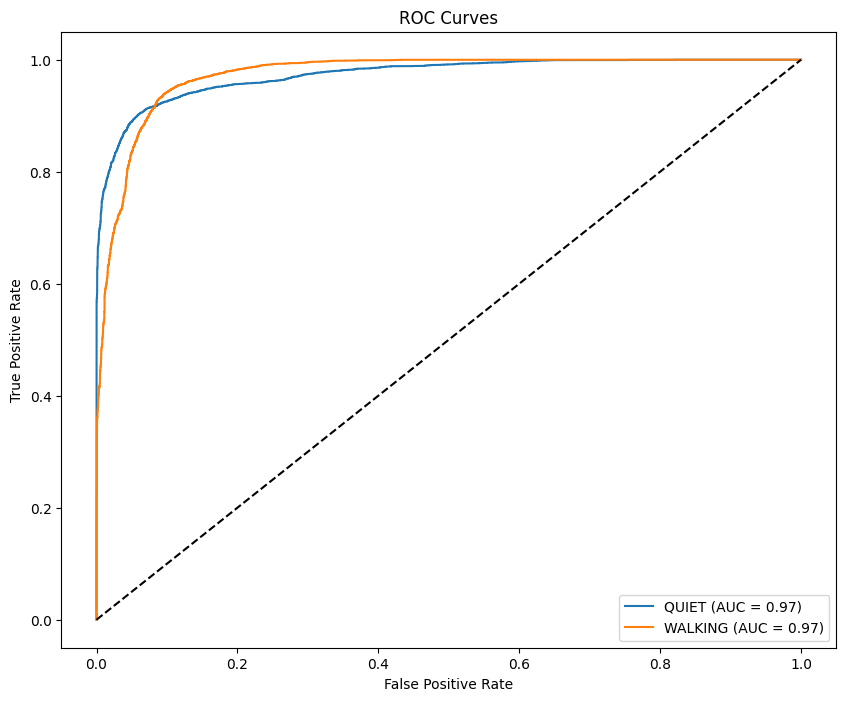

In [114]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau

input_channels = 1  # מספר הערוצים של הנתונים
hidden_size = 64
output_size = len(label_encoder.classes_)
tf_feature_dim = time_freq_features.shape[1]  # מספר המאפיינים של זמן-תדר
spatial_feature_dim = spatial_energy_features.shape[1]  # מספר המאפיינים של אנרגיה מרחבית

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# הגדרת המודל
model = DualStreamModel(
    input_channels=input_channels,
    hidden_size=hidden_size,
    output_size=output_size,
    tf_feature_dim=tf_feature_dim,
    spatial_feature_dim=spatial_feature_dim,
    num_cnn_layers=3,
    initial_filters=32,
    gru_layers=2,
    gru_dropout=0.3,
    bidirectional=True
).to(device)

# אופטימייזר וקריטריון

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

scheduler = ReduceLROnPlateau(optimizer, mode='min',factor=0.5,patience=3,verbose=True)
# יצירת אובייקט אנליזה
analyzer = ModelAnalyzer()

# פרמטרים
num_epochs = 150
patience = 10
best_val_loss = float('inf')
early_stop_counter = 0

# לולאת האימון
for epoch in range(num_epochs):
    # אימון
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch in train_loader:
        X_spec, X_mfcc, X_chroma, X_tf, X_spatial, y = [b.to(device) for b in batch]
        X_spec, X_mfcc, X_chroma = [x.unsqueeze(1) for x in [X_spec, X_mfcc, X_chroma]]

        optimizer.zero_grad()
        outputs = model(X_spec, X_mfcc, X_chroma, X_tf, X_spatial)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
       
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += y.size(0)
        correct_train += (predicted == y).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = correct_train / total_train

    # ולידציה
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch in val_loader:
            X_spec, X_mfcc, X_chroma, X_tf, X_spatial, y = [b.to(device) for b in batch]
            X_spec, X_mfcc, X_chroma = [x.unsqueeze(1) for x in [X_spec, X_mfcc, X_chroma]]

            outputs = model(X_spec, X_mfcc, X_chroma, X_tf, X_spatial)
            loss = criterion(outputs, y)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += y.size(0)
            correct_val += (predicted == y).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct_val / total_val

    # עדכון סטטיסטיקות
    current_lr = optimizer.param_groups[0]['lr']
    analyzer.add_epoch_stats(epoch, train_loss, train_accuracy, val_loss, val_accuracy, current_lr)
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} Train Acc: {train_accuracy:.4f} "
          f"Val Loss: {val_loss:.4f} Val Acc: {val_accuracy:.4f} "
          f"LR: {current_lr:.6f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break

# בדיקה סופית והערכה
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_predictions = []
test_probabilities = []
test_true_labels = []

with torch.no_grad():
    for batch in test_loader:
        X_spec, X_mfcc, X_chroma, X_tf, X_spatial, y = [b.to(device) for b in batch]
        X_spec, X_mfcc, X_chroma = [x.unsqueeze(1) for x in [X_spec, X_mfcc, X_chroma]]

        outputs = model(X_spec, X_mfcc, X_chroma, X_tf, X_spatial)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        test_predictions.extend(predicted.cpu().numpy())
        test_probabilities.extend(probabilities.cpu().numpy())
        test_true_labels.extend(y.cpu().numpy())

# ניתוח תוצאות
test_predictions = np.array(test_predictions)
test_probabilities = np.array(test_probabilities)
test_true_labels = np.array(test_true_labels)

# מטריקות ביצועים
test_accuracy = (test_predictions == test_true_labels).mean()
print("\nPerformance Metrics:")
print("-" * 50)
print(f"Test Accuracy:       {test_accuracy:.2%}")
print(f"Validation Accuracy: {analyzer.training_history['val_acc'][-1]:.2%}")
print(f"Training Accuracy:   {analyzer.training_history['train_acc'][-1]:.2%}")
print("-" * 50)

# ויזואליזציה
analyzer.plot_training_history()
analyzer.plot_confusion_matrix(test_true_labels, test_predictions)
class_names = label_encoder.classes_
analyzer.plot_roc_curves(test_true_labels, test_probabilities, class_names)

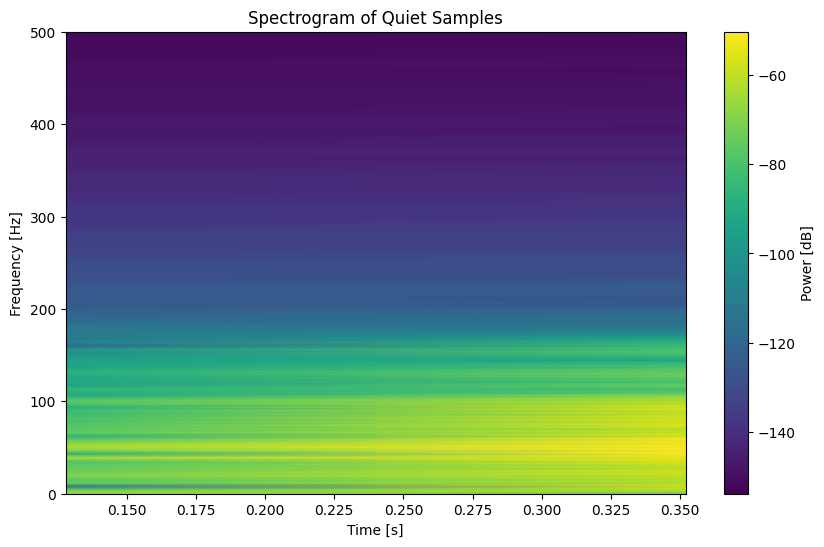

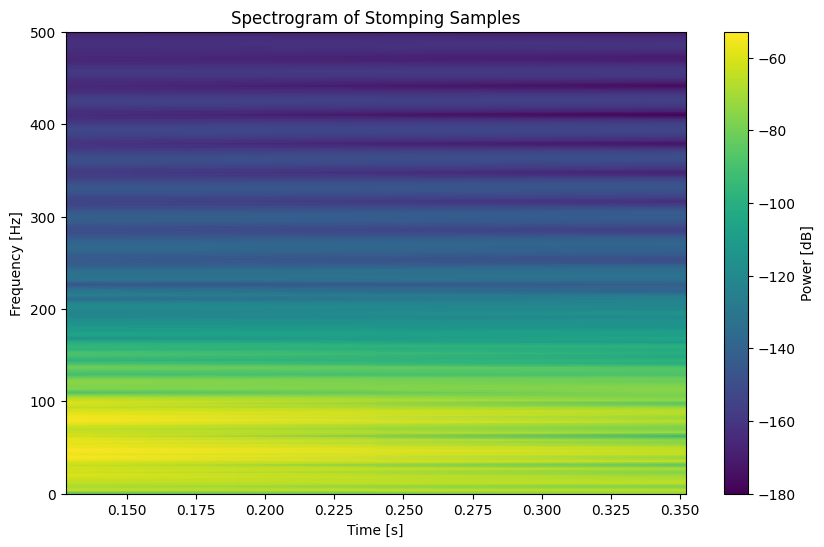

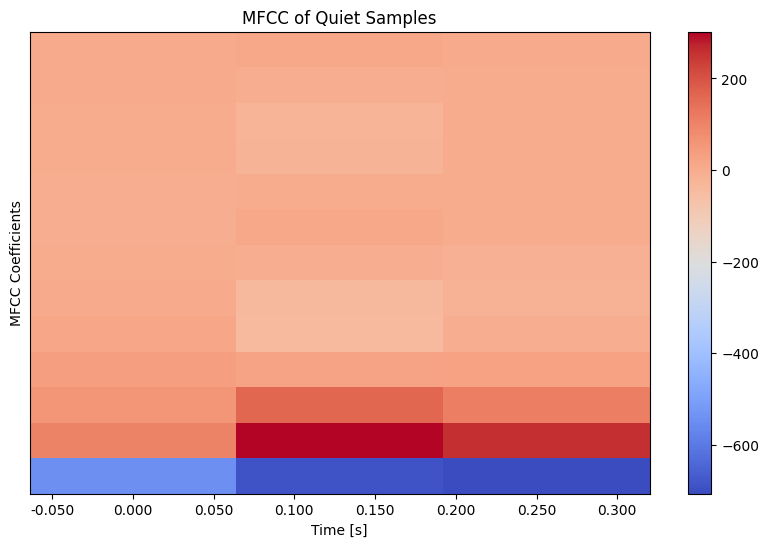

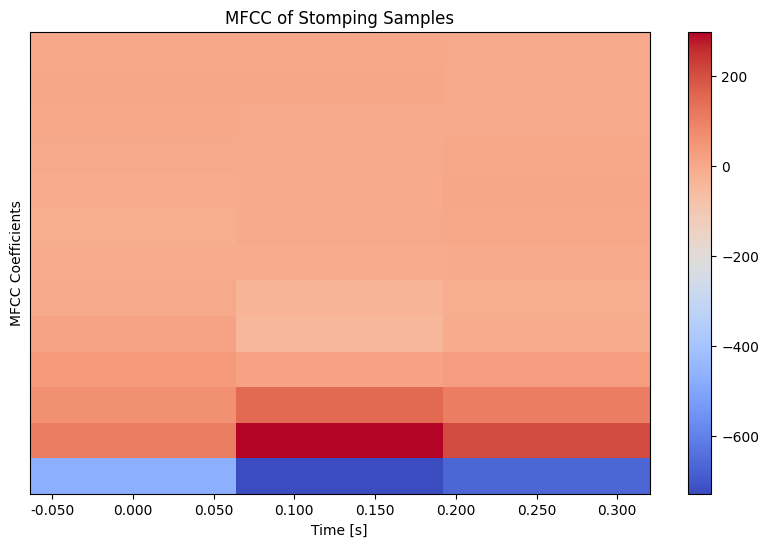

d:\לימודים\פרויקט\.venv\Lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


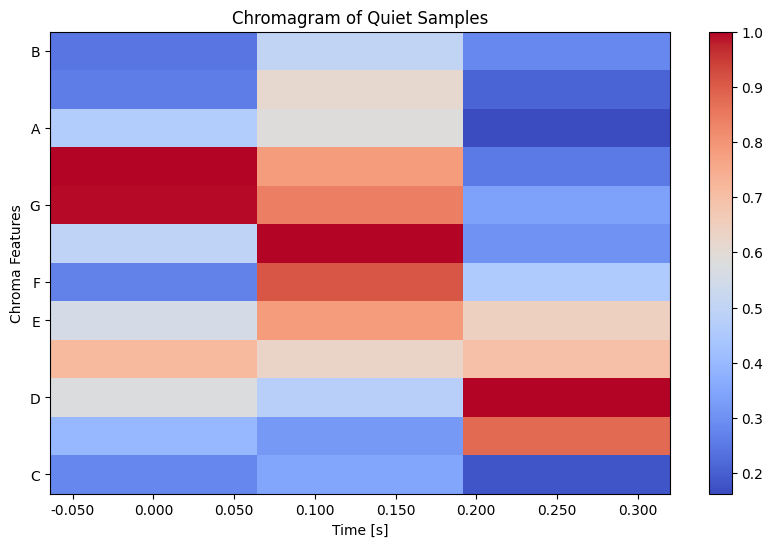

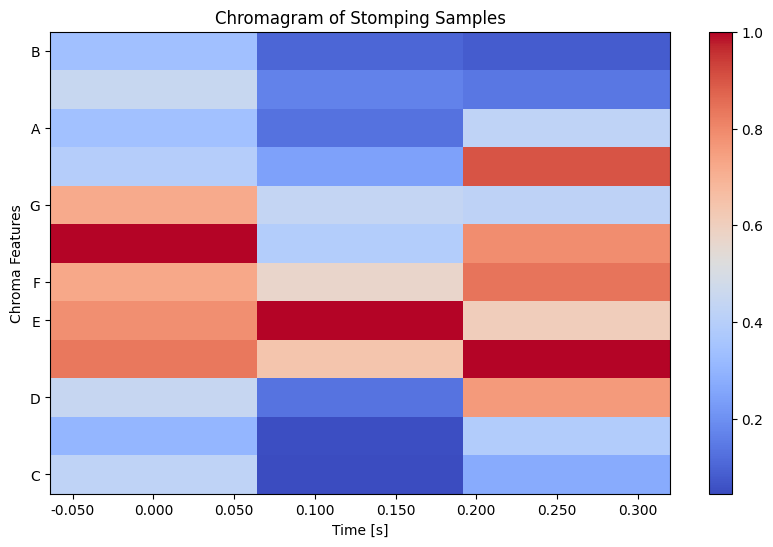

In [22]:
def plot_spectrogram(signal, title, sample_rate=1000):
    f, t, Sxx = spectrogram(signal, fs=sample_rate)
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
    plt.title(title)
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [s]')
    plt.colorbar(label='Power [dB]')
    plt.show()

# Example: Plot spectrograms for sample data
# Assuming quiet_windows and walking_windows_matrix are pre-loaded arrays
plot_spectrogram(quiet_windows[0], title="Spectrogram of Quiet Samples")
plot_spectrogram(walking_windows_matrix[0], title="Spectrogram of Stomping Samples")

# Function to plot MFCC
def plot_mfcc(signal, title, sr=1000, n_mfcc=13):
    mfcc = extract_mfcc(signal, sr, n_mfcc)
    plt.figure(figsize=(10, 6))
    librosa.display.specshow(mfcc, x_axis='time', sr=sr, hop_length=128, cmap='coolwarm')
    plt.colorbar()
    plt.title(title)
    plt.xlabel('Time [s]')
    plt.ylabel('MFCC Coefficients')
    plt.show()

# Function to plot Chromagram
def plot_chromagram(signal, title, sr=1000):
    chroma = extract_chromagram(signal, sr)
    plt.figure(figsize=(10, 6))
    librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', sr=sr, hop_length=128, cmap='coolwarm')
    plt.colorbar()
    plt.title(title)
    plt.xlabel('Time [s]')
    plt.ylabel('Chroma Features')
    plt.show()

# Plot MFCC and Chromagram for samples
plot_mfcc(quiet_windows[0], title="MFCC of Quiet Samples")
plot_mfcc(walking_windows_matrix[0], title="MFCC of Stomping Samples")

plot_chromagram(quiet_windows[0], title="Chromagram of Quiet Samples")
plot_chromagram(walking_windows_matrix[0], title="Chromagram of Stomping Samples")
